# Facebook Recruiting - Human or Bot?

In [2]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

# system
import os
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parents[2]))  # workaround to resolve my helper module above

# dataframe
import polars as pl
import polars.selectors as cs

# modules
from modules.plotting import *
from modules.polars_helpers import *

# stats
from scipy.stats import pearsonr

parent_dir = Path.cwd().parent

DATA_PATH = str(parent_dir / "data") + "/"
print(DATA_PATH)

RANDOM_SEED = 42

/Users/luiscruz/Desktop/kaggle_challenges/classification/facebook-recruiting-iv-human-or-bot/data/


The goal of this challenge is to classify whether a bidder is a human or a bot based on bidder info. We then have two tables:
Bidder (train.csv):
- bidder_id
- payment_account
- address
- outcome (target) where 1 is a robot and 0 is a human

Bids (bids.csv):
- bid_id - unique id for this bid
- bidder_id – Unique identifier of a bidder (same as the bidder_id used in train.csv and test.csv)
- auction – Unique identifier of an auction
- merchandise –  The category of the auction site campaign, which means the bidder might come to this site by way of searching for "home goods" but ended up bidding for "sporting goods" - and that leads to this field being "home goods". This categorical field could be a search term, or online advertisement. 
- device – Phone model of a visitor
- time - Time that the bid is made (transformed to protect privacy).
- country - The country that the IP belongs to
- ip – IP address of a bidder (obfuscated to protect privacy).
- url - url where the bidder was referred from (obfuscated to protect privacy)

In [3]:
train = pl.read_csv(DATA_PATH + "train.csv")
test = pl.read_csv(DATA_PATH + "test.csv")

bids = pl.read_csv(DATA_PATH + "bids.csv")

In [4]:
train.shape, test.shape, bids.shape

((2013, 4), (4700, 3), (7656334, 9))

In [5]:
train

bidder_id,payment_account,address,outcome
str,str,str,f64
"""91a3c57b13234af24875c56fb7e2b2…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0.0
"""624f258b49e77713fc34034560f93f…","""a3d2de7675556553a5f08e4c88d2c2…","""ae87054e5a97a8f840a3991d12611f…",0.0
"""1c5f4fc669099bfbfac515cd26997b…","""a3d2de7675556553a5f08e4c88d2c2…","""92520288b50f03907041887884ba49…",0.0
"""4bee9aba2abda51bf43d639013d6ef…","""51d80e233f7b6a7dfdee484a3c120f…","""4cb9717c8ad7e88a9a284989dd79b9…",0.0
"""4ab12bc61c82ddd9c2d65e60555808…","""a3d2de7675556553a5f08e4c88d2c2…","""2a96c3ce94b3be921e0296097b88b5…",0.0
…,…,…,…
"""369515b3af4f8ca582f90271d30b14…","""a1f85275793c4a782f0a668711f41b…","""e6882cf204a9482edd042b6e31791d…",0.0
"""f939c17ffc7c39ac9b35b69e5e7517…","""a3d2de7675556553a5f08e4c88d2c2…","""b9b03d5a127eb07aeb9163cdcf524e…",0.0
"""c806dbb2decba0ed3c4ff5e2e60a74…","""a3d2de7675556553a5f08e4c88d2c2…","""d02c2b288b8aabd79ff47118aff41a…",0.0


In [6]:
test

bidder_id,payment_account,address
str,str,str
"""49bb5a3c944b8fc337981cc7a9ccae…","""a3d2de7675556553a5f08e4c88d2c2…","""5d9fa1b71f992e7c7a106ce4b07a0a…"
"""a921612b85a1494456e74c09393ccb…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…"
"""6b601e72a4d264dab9ace9d7b229b4…","""925381cce086b8cc9594eee1c77edf…","""a3d2de7675556553a5f08e4c88d2c2…"
"""eaf0ed0afc9689779417274b479172…","""a3d2de7675556553a5f08e4c88d2c2…","""b5714de1fd69d4a0d2e39d59e53fe9…"
"""cdecd8d02ed8c6037e38042c7745f6…","""a3d2de7675556553a5f08e4c88d2c2…","""c3b363a3c3b838d58c85acf0fc9964…"
…,…,…
"""bef56983ba78b2ee064443ae959728…","""0f235a6dfea5a5885d63968826b748…","""a98a4841db165de919d29cb49d0bc3…"
"""4da45cc915c32d4368ac7e773d92d4…","""9e0adf7481c422654d4d0a849e0e50…","""e23d9777cddc347de82d839b2e54b2…"
"""0d0e6220bf59ab9a0c5b5987fb2c34…","""7df4ebd184668b4257f740b11d4519…","""b650404e1ab5d177020221277c3e93…"


In [7]:
(bids.shape[0] - train.shape[0]), (bids.shape[0] - test.shape[0])

(7654321, 7651634)

The main challenge here will be figuring out the correct features to use to create summary statistics that can be associated to each bidder, in order to make a prediction. Tables cannot be used in the current state, because this would lead to classifying bids rather than bidders. To classify bidders, rows must have individual bidder information so the outcome can be properly attributed

In [8]:
train.null_count()

bidder_id,payment_account,address,outcome
u32,u32,u32,u32
0,0,0,0


In [9]:
test.null_count()

bidder_id,payment_account,address
u32,u32,u32
0,0,0


Train and Test have no nulls so we can start engineering features from the bids table onto train and test

## Feature Engineering

In [10]:
bids.null_count()

bid_id,bidder_id,auction,merchandise,device,time,country,ip,url
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,8859,0,0


In [11]:
bids.describe()

statistic,bid_id,bidder_id,auction,merchandise,device,time,country,ip,url
str,f64,str,str,str,str,f64,str,str,str
"""count""",7.656334e6,"""7656334""","""7656334""","""7656334""","""7656334""",7.656334e6,"""7647475""","""7656334""","""7656334"""
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,"""8859""","""0""","""0"""
"""mean""",3828166.5,null,null,null,null,9.6980e15,null,null,null
"""std""",2.2102e6,null,null,null,null,5.2505e13,null,null,null
"""min""",0.0,"""001068c415025a009fee375a12cff4…","""00270""","""auto parts""","""phone0""",9.6319e15,"""ad""","""0.0.101.184""","""00018jv10bfpamj"""
"""25%""",1.914083e6,null,null,null,null,9.6411e15,null,null,null
"""50%""",3.828167e6,null,null,null,null,9.7007e15,null,null,null
"""75%""",5.74225e6,null,null,null,null,9.7617e15,null,null,null
"""max""",7.656333e6,"""fff2c070d8200e0a09150bd81452ce…","""zzzy7""","""sporting goods""","""phone999""",9.7729e15,"""zz""","""99.99.99.217""","""zzzzs4vfq9tfa1y"""


Bids have mostly categorical features, except for the time which is specified as an f64. 
Countries are null in 8859 entries out of over 7 million in total. We could safely drop them since they represent close to 0.1% of total data

In [12]:
bids = bids.drop_nulls()
bids.null_count()

bid_id,bidder_id,auction,merchandise,device,time,country,ip,url
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0


In [13]:
bids.shape

(7647475, 9)

In [14]:
train["outcome"].value_counts()

outcome,count
f64,u32
1.0,103
0.0,1910


Classes are very unbalanced on the training set. This will have to be dealt with prior to training the model to avoid overfitting and having high accuracy due to probability

### Num of devices per bidder

In [15]:
n_devices_per_bidder = bids.group_by("bidder_id").n_unique().select(["bidder_id", "device"])
n_devices_per_bidder

bidder_id,device
str,u32
"""300bb4c9816a7064b106c9c6cec2f5…",3
"""9393cc68d0357d7b200a94fdf93ee3…",24
"""24bf80f893032090cca06d4d001146…",1
"""466ebf78d7326a38db1e19fdc1c70e…",1
"""1992314a8d692be0cfee8e557a9117…",4
…,…
"""526bcde22673b8c5faa642df2662ca…",21
"""5af68eabf1ad92562c1cca4df99437…",379
"""3ef1f85040a0c136857e7baccc95d4…",2


In [16]:
train = train.join(n_devices_per_bidder, on="bidder_id", how="left")
train

bidder_id,payment_account,address,outcome,device
str,str,str,f64,u32
"""91a3c57b13234af24875c56fb7e2b2…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,14
"""624f258b49e77713fc34034560f93f…","""a3d2de7675556553a5f08e4c88d2c2…","""ae87054e5a97a8f840a3991d12611f…",0.0,2
"""1c5f4fc669099bfbfac515cd26997b…","""a3d2de7675556553a5f08e4c88d2c2…","""92520288b50f03907041887884ba49…",0.0,2
"""4bee9aba2abda51bf43d639013d6ef…","""51d80e233f7b6a7dfdee484a3c120f…","""4cb9717c8ad7e88a9a284989dd79b9…",0.0,1
"""4ab12bc61c82ddd9c2d65e60555808…","""a3d2de7675556553a5f08e4c88d2c2…","""2a96c3ce94b3be921e0296097b88b5…",0.0,53
…,…,…,…,…
"""369515b3af4f8ca582f90271d30b14…","""a1f85275793c4a782f0a668711f41b…","""e6882cf204a9482edd042b6e31791d…",0.0,4
"""f939c17ffc7c39ac9b35b69e5e7517…","""a3d2de7675556553a5f08e4c88d2c2…","""b9b03d5a127eb07aeb9163cdcf524e…",0.0,1
"""c806dbb2decba0ed3c4ff5e2e60a74…","""a3d2de7675556553a5f08e4c88d2c2…","""d02c2b288b8aabd79ff47118aff41a…",0.0,2


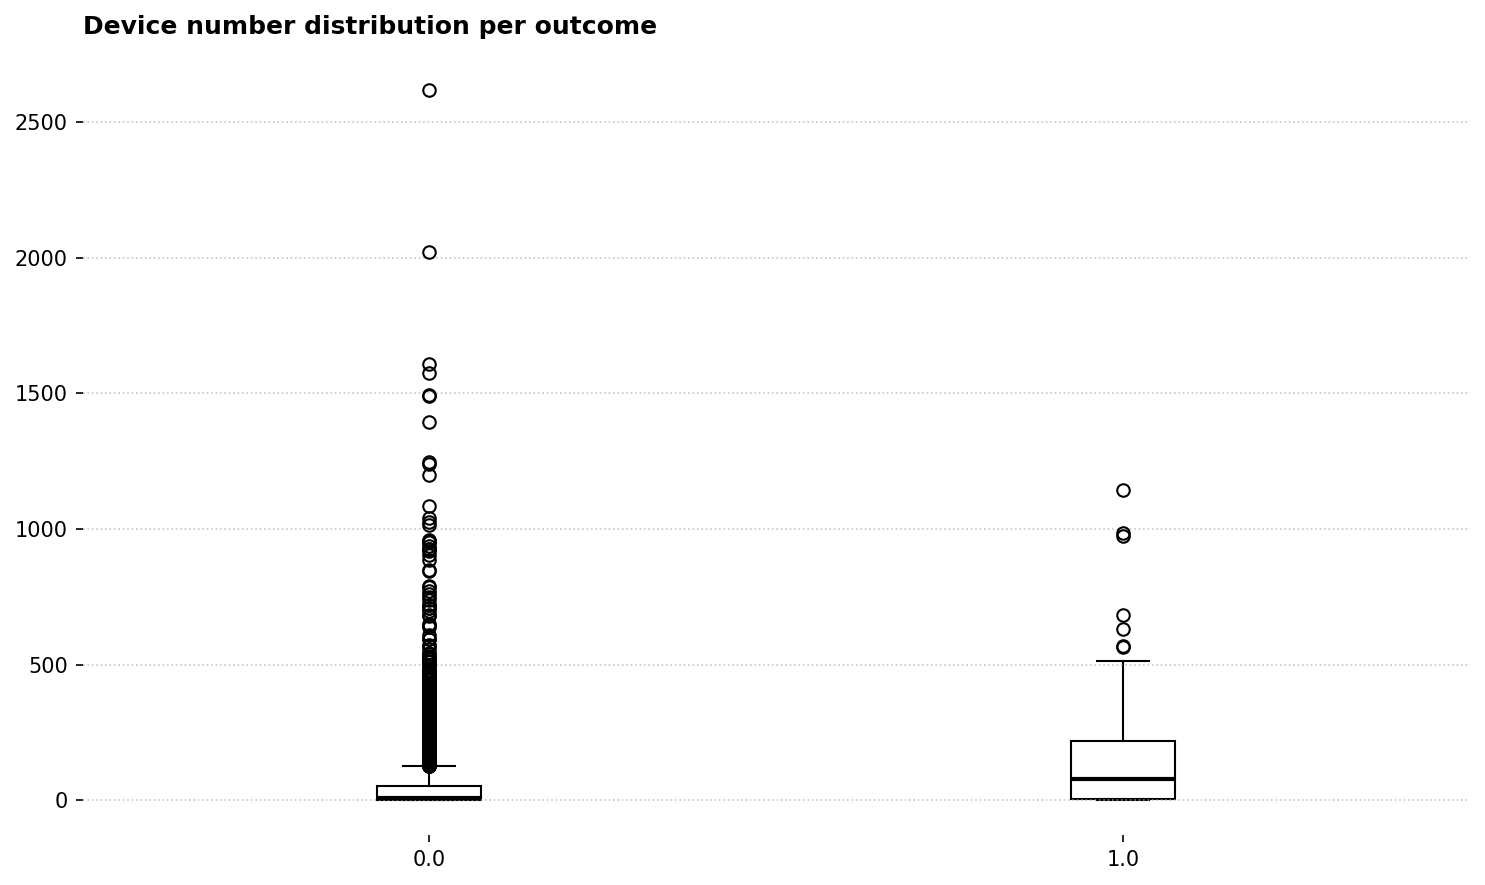

In [17]:
wide_on_outcome_device, outcomes = pivot_table_on_column(train, "outcome", "device")

multiple_boxplots(wide_on_outcome_device, outcomes, "Device number distribution per outcome")

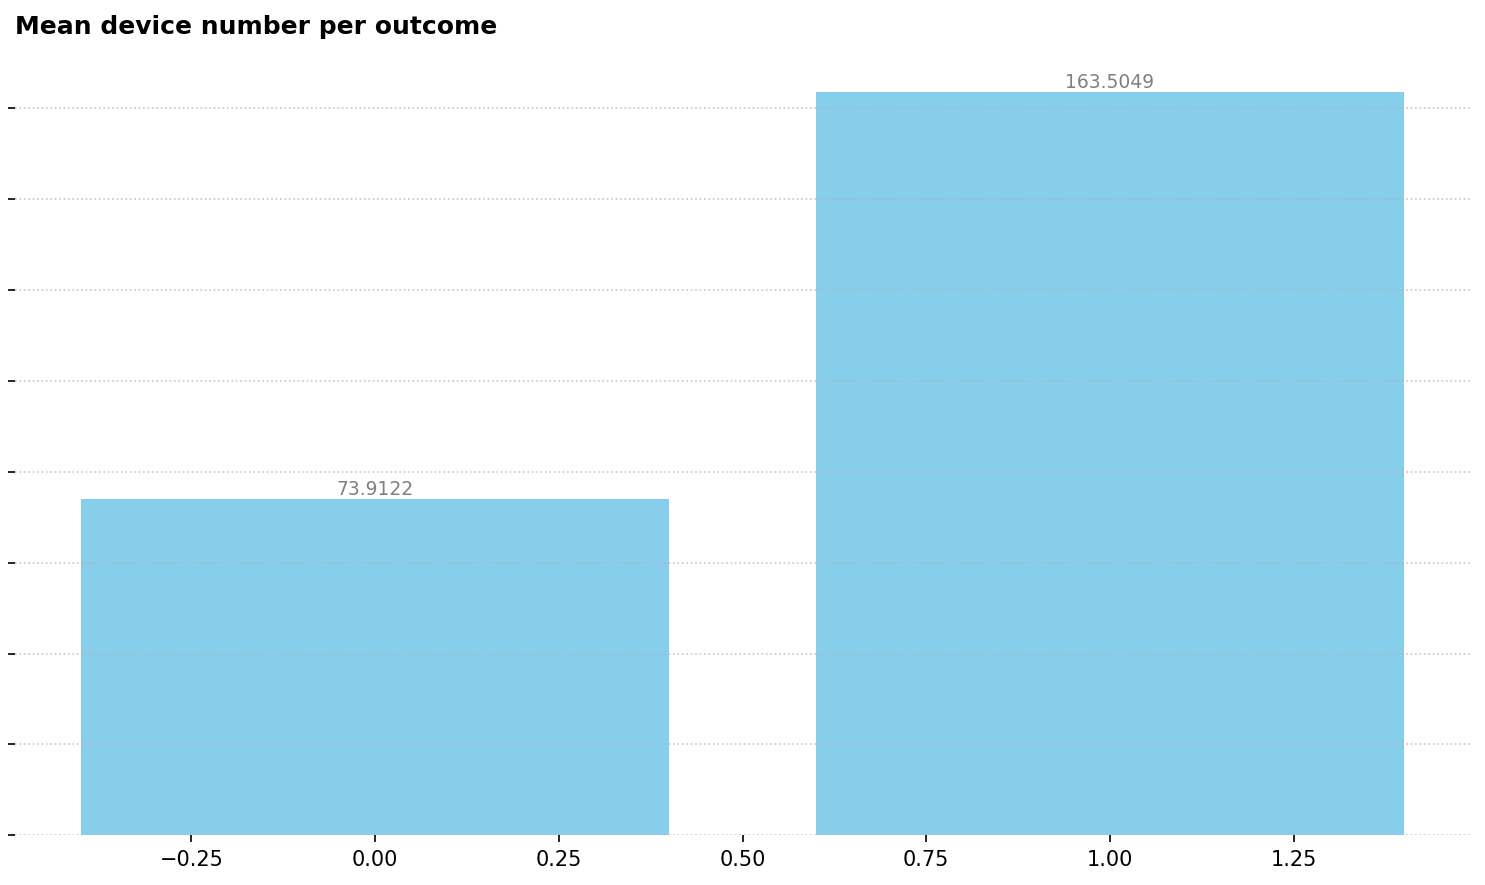

In [18]:
multiple_barplot(wide_on_outcome_device, outcomes, "Mean device number per outcome")

Bots have a mean number of devices over double the mean count of humans, even though some outlier humans have several thousand devices, most are concentrated on the lower end, lowering the mean.

### Num of auctions per bidder

In [19]:
bids["auction"].n_unique()

15051

In [20]:
auction_count_per_bidder = bids.group_by("bidder_id").n_unique().select(["bidder_id", "auction"])

auction_count_per_bidder

bidder_id,auction
str,u32
"""0c44f546ed40a8ccfc2e985c6d1c62…",1
"""72dd0e4788d25f62cc2ba942bb9499…",27
"""b53b678016f0d522dc48b24919be07…",206
"""de8943f2b113702c98ef695888b7d0…",1
"""372bf02911448b7f62cc861074a7ac…",1
…,…
"""19b39b852ed4abf1ba5b095829e25b…",5
"""d66bbdfa8ebbdde41183bca06bfa4f…",4
"""59998f2c7299efed20dbb68df23a53…",93


In [21]:
train = train.join(auction_count_per_bidder, on="bidder_id", how="left")
train

bidder_id,payment_account,address,outcome,device,auction
str,str,str,f64,u32,u32
"""91a3c57b13234af24875c56fb7e2b2…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,14,18
"""624f258b49e77713fc34034560f93f…","""a3d2de7675556553a5f08e4c88d2c2…","""ae87054e5a97a8f840a3991d12611f…",0.0,2,1
"""1c5f4fc669099bfbfac515cd26997b…","""a3d2de7675556553a5f08e4c88d2c2…","""92520288b50f03907041887884ba49…",0.0,2,4
"""4bee9aba2abda51bf43d639013d6ef…","""51d80e233f7b6a7dfdee484a3c120f…","""4cb9717c8ad7e88a9a284989dd79b9…",0.0,1,1
"""4ab12bc61c82ddd9c2d65e60555808…","""a3d2de7675556553a5f08e4c88d2c2…","""2a96c3ce94b3be921e0296097b88b5…",0.0,53,23
…,…,…,…,…,…
"""369515b3af4f8ca582f90271d30b14…","""a1f85275793c4a782f0a668711f41b…","""e6882cf204a9482edd042b6e31791d…",0.0,4,25
"""f939c17ffc7c39ac9b35b69e5e7517…","""a3d2de7675556553a5f08e4c88d2c2…","""b9b03d5a127eb07aeb9163cdcf524e…",0.0,1,1
"""c806dbb2decba0ed3c4ff5e2e60a74…","""a3d2de7675556553a5f08e4c88d2c2…","""d02c2b288b8aabd79ff47118aff41a…",0.0,2,1


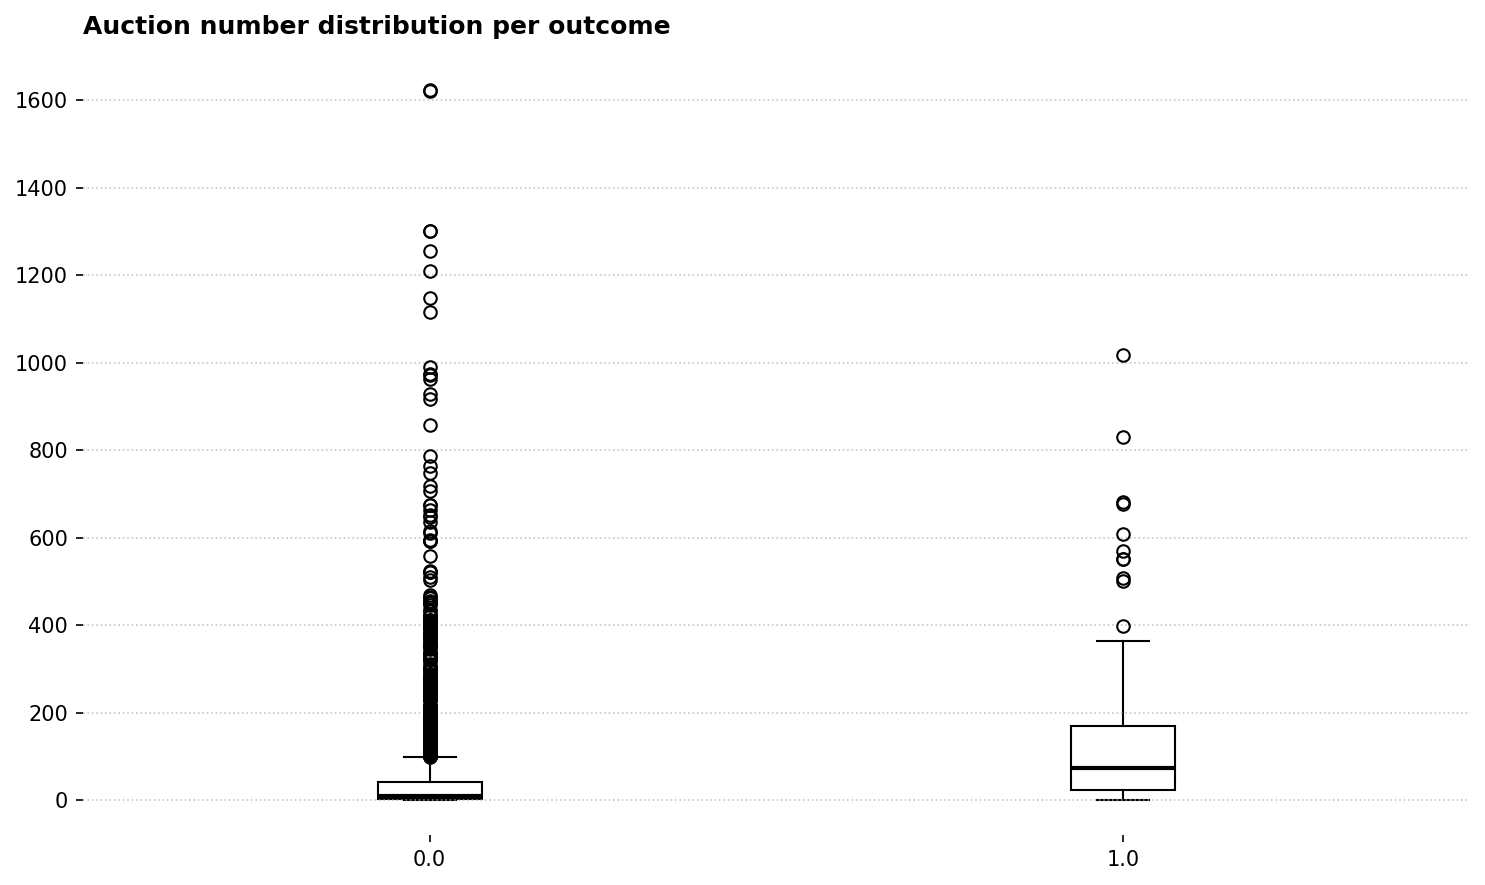

In [22]:
wide_on_outcome_auction, outcomes = pivot_table_on_column(train, "outcome", "auction")

multiple_boxplots(wide_on_outcome_auction, outcomes, "Auction number distribution per outcome")

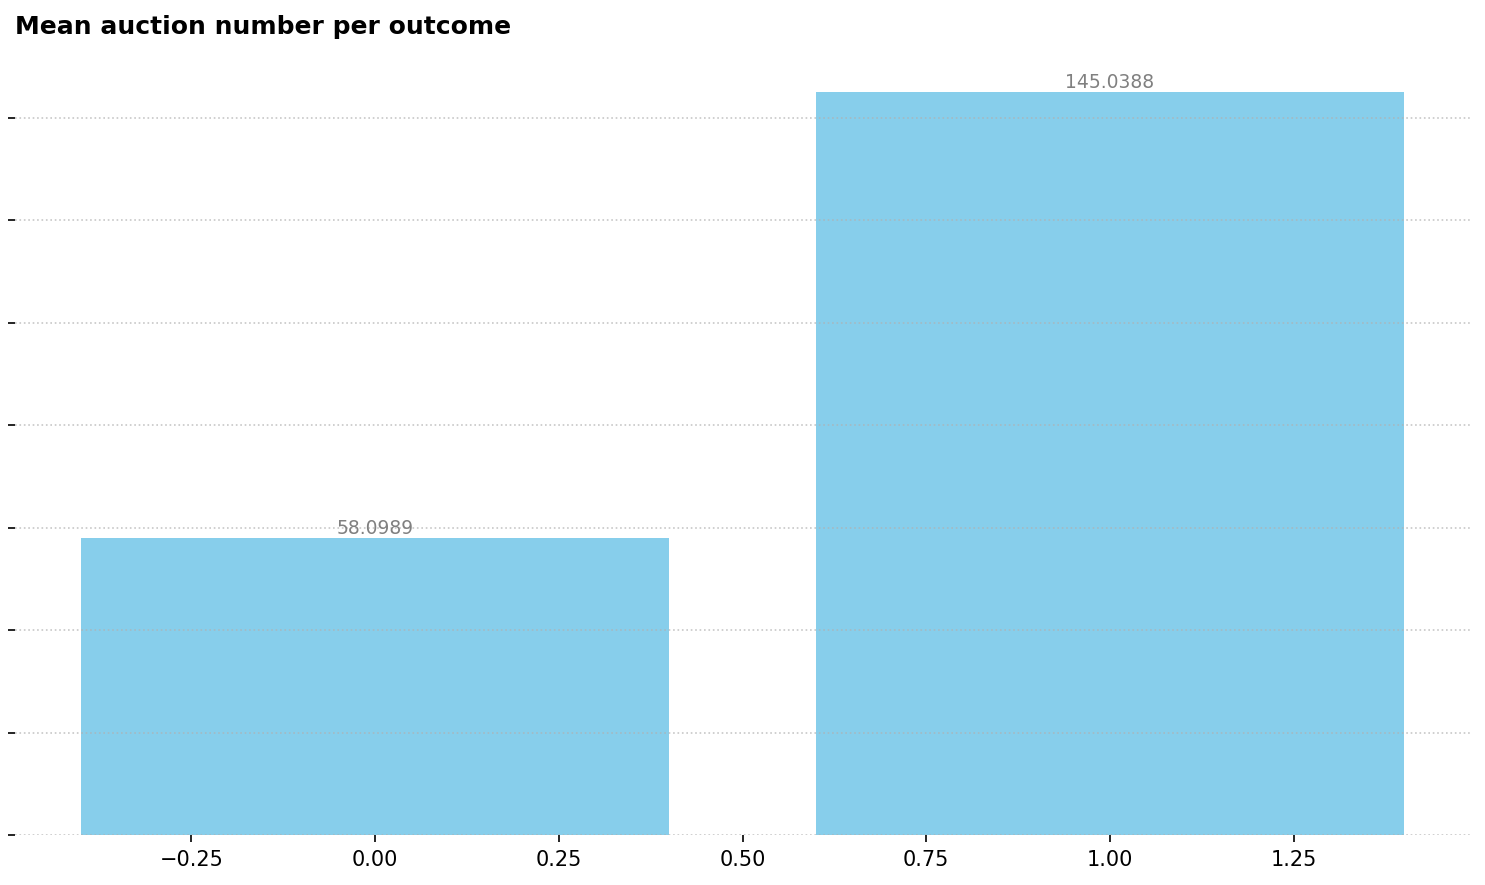

In [23]:
multiple_barplot(wide_on_outcome_auction, outcomes, "Mean auction number per outcome")

Once again, bots are in almost 3x as many auctions as humans, which makes the auction could a likely candidate to classify a bidder

In [24]:
bids

bid_id,bidder_id,auction,merchandise,device,time,country,ip,url
i64,str,str,str,str,i64,str,str,str
0,"""8dac2b259fd1c6d1120e519fb1ac14…","""ewmzr""","""jewelry""","""phone0""",9759243157894736,"""us""","""69.166.231.58""","""vasstdc27m7nks3"""
1,"""668d393e858e8126275433046bbd35…","""aeqok""","""furniture""","""phone1""",9759243157894736,"""in""","""50.201.125.84""","""jmqlhflrzwuay9c"""
2,"""aa5f360084278b35d746fa6af3a7a1…","""wa00e""","""home goods""","""phone2""",9759243157894736,"""py""","""112.54.208.157""","""vasstdc27m7nks3"""
3,"""3939ac3ef7d472a59a9c5f893dd3e3…","""jefix""","""jewelry""","""phone4""",9759243157894736,"""in""","""18.99.175.133""","""vasstdc27m7nks3"""
4,"""8393c48eaf4b8fa96886edc7cf27b3…","""jefix""","""jewelry""","""phone5""",9759243157894736,"""in""","""145.138.5.37""","""vasstdc27m7nks3"""
…,…,…,…,…,…,…,…,…
7656329,"""626159dd6f2228ede002d9f9340f75…","""3e64w""","""jewelry""","""phone91""",9709222052631578,"""ru""","""140.204.227.63""","""cghhmomsaxi6pug"""
7656330,"""a318ea333ceee1ba39a49447638613…","""xn0y0""","""mobile""","""phone236""",9709222052631578,"""pl""","""24.232.159.118""","""wgggpdg2gx5pesn"""
7656331,"""f5b2bbad20d1d7ded3ed960393bec0…","""gja6c""","""sporting goods""","""phone80""",9709222052631578,"""za""","""80.237.28.246""","""5xgysg14grlersa"""


### Num of Merchandises per bidder

In [25]:
merch_count_per_bidder = bids.group_by("bidder_id").n_unique().select(["bidder_id", "merchandise"])

merch_count_per_bidder

bidder_id,merchandise
str,u32
"""0e8212e286ee36da8945c2480e3664…",1
"""a2fca0af76b3e867767068d121b72b…",1
"""adfa9cafb96e4c433e015833dce4ae…",1
"""c6db45b030e655e4046c94ef213f80…",1
"""4c4431ec9b6e683bdc5a3118d51401…",1
…,…
"""693bb841ef77a088459cf53ebcbde3…",1
"""6d6a5ff71c061e78473cf1489b52ec…",1
"""843a2039ce072a0a23c9bd647298e9…",1


In [26]:
train = train.join(merch_count_per_bidder, on="bidder_id", how="left")
train

bidder_id,payment_account,address,outcome,device,auction,merchandise
str,str,str,f64,u32,u32,u32
"""91a3c57b13234af24875c56fb7e2b2…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,14,18,1
"""624f258b49e77713fc34034560f93f…","""a3d2de7675556553a5f08e4c88d2c2…","""ae87054e5a97a8f840a3991d12611f…",0.0,2,1,1
"""1c5f4fc669099bfbfac515cd26997b…","""a3d2de7675556553a5f08e4c88d2c2…","""92520288b50f03907041887884ba49…",0.0,2,4,1
"""4bee9aba2abda51bf43d639013d6ef…","""51d80e233f7b6a7dfdee484a3c120f…","""4cb9717c8ad7e88a9a284989dd79b9…",0.0,1,1,1
"""4ab12bc61c82ddd9c2d65e60555808…","""a3d2de7675556553a5f08e4c88d2c2…","""2a96c3ce94b3be921e0296097b88b5…",0.0,53,23,1
…,…,…,…,…,…,…
"""369515b3af4f8ca582f90271d30b14…","""a1f85275793c4a782f0a668711f41b…","""e6882cf204a9482edd042b6e31791d…",0.0,4,25,1
"""f939c17ffc7c39ac9b35b69e5e7517…","""a3d2de7675556553a5f08e4c88d2c2…","""b9b03d5a127eb07aeb9163cdcf524e…",0.0,1,1,1
"""c806dbb2decba0ed3c4ff5e2e60a74…","""a3d2de7675556553a5f08e4c88d2c2…","""d02c2b288b8aabd79ff47118aff41a…",0.0,2,1,1


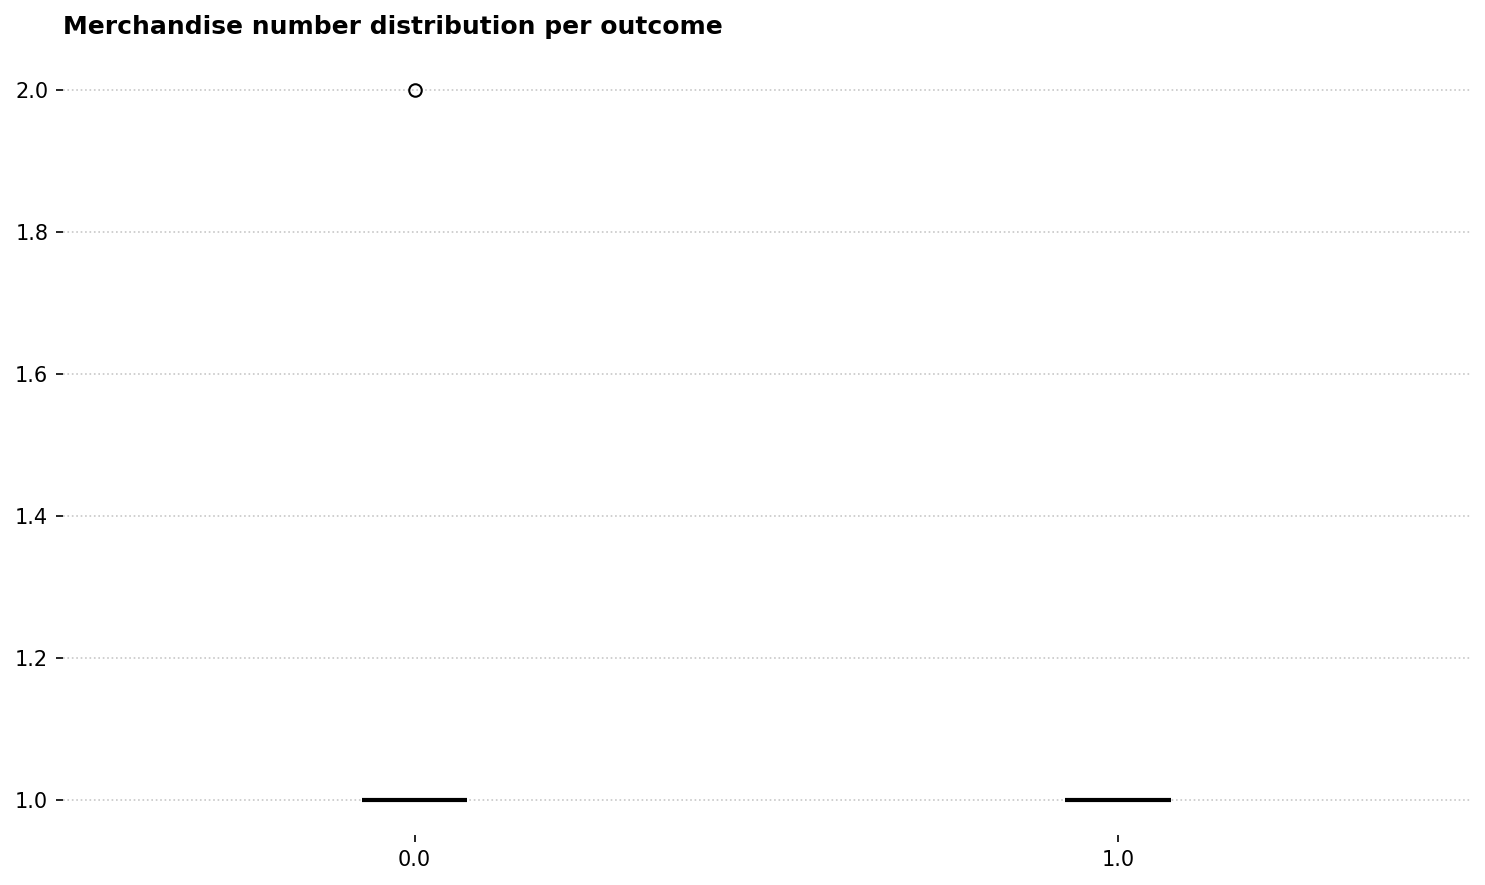

In [27]:
wide_on_outcome_merch, outcomes = pivot_table_on_column(train, "outcome", "merchandise")

multiple_boxplots(wide_on_outcome_merch, outcomes, "Merchandise number distribution per outcome")

In [28]:
wide_on_outcome_merch.filter(pl.col("0.0") == 2)

0.0,1.0
i64,i64
2,null


Seems that neither people nor bots bid on several kinds of merchandise, only one, with one occurrence of a person bidding on two kinds of merchandise. This will hardly be useful for predicting 

In [29]:
train = train.drop("merchandise")
train

bidder_id,payment_account,address,outcome,device,auction
str,str,str,f64,u32,u32
"""91a3c57b13234af24875c56fb7e2b2…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,14,18
"""624f258b49e77713fc34034560f93f…","""a3d2de7675556553a5f08e4c88d2c2…","""ae87054e5a97a8f840a3991d12611f…",0.0,2,1
"""1c5f4fc669099bfbfac515cd26997b…","""a3d2de7675556553a5f08e4c88d2c2…","""92520288b50f03907041887884ba49…",0.0,2,4
"""4bee9aba2abda51bf43d639013d6ef…","""51d80e233f7b6a7dfdee484a3c120f…","""4cb9717c8ad7e88a9a284989dd79b9…",0.0,1,1
"""4ab12bc61c82ddd9c2d65e60555808…","""a3d2de7675556553a5f08e4c88d2c2…","""2a96c3ce94b3be921e0296097b88b5…",0.0,53,23
…,…,…,…,…,…
"""369515b3af4f8ca582f90271d30b14…","""a1f85275793c4a782f0a668711f41b…","""e6882cf204a9482edd042b6e31791d…",0.0,4,25
"""f939c17ffc7c39ac9b35b69e5e7517…","""a3d2de7675556553a5f08e4c88d2c2…","""b9b03d5a127eb07aeb9163cdcf524e…",0.0,1,1
"""c806dbb2decba0ed3c4ff5e2e60a74…","""a3d2de7675556553a5f08e4c88d2c2…","""d02c2b288b8aabd79ff47118aff41a…",0.0,2,1


### Pattern in merchandise the bidder is bidding on

In [30]:
bids.null_count()

bid_id,bidder_id,auction,merchandise,device,time,country,ip,url
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0


In [31]:
bids["merchandise"].unique()

merchandise
str
"""mobile"""
"""sporting goods"""
"""books and music"""
"""computers"""
"""office equipment"""
"""home goods"""
"""furniture"""
"""auto parts"""
"""jewelry"""


In [32]:
max_kind_of_merch_per_bidder = bids.group_by("bidder_id").max().select(["bidder_id", "merchandise"])
max_kind_of_merch_per_bidder

bidder_id,merchandise
str,str
"""459ea22b6b51936d0788de9f78a354…","""mobile"""
"""dc752fa41d974bf688d25ea9d18e9a…","""mobile"""
"""77bc113594866d4902d6f867a45675…","""sporting goods"""
"""e50426efab1e9d60b8f7258130f879…","""mobile"""
"""920bbc37a00224e524821a60d5dd00…","""home goods"""
…,…
"""ae588c9927a941ece626c971f882e2…","""jewelry"""
"""661569e79532c77348185d4d056858…","""office equipment"""
"""bdad7062bc08b8a1419e5517444a76…","""office equipment"""


In [33]:
max_kind_of_merch_per_bidder.null_count()

bidder_id,merchandise
u32,u32
0,0


In [34]:
train = train.join(max_kind_of_merch_per_bidder, on="bidder_id", how="left")
train

bidder_id,payment_account,address,outcome,device,auction,merchandise
str,str,str,f64,u32,u32,str
"""91a3c57b13234af24875c56fb7e2b2…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,14,18,"""home goods"""
"""624f258b49e77713fc34034560f93f…","""a3d2de7675556553a5f08e4c88d2c2…","""ae87054e5a97a8f840a3991d12611f…",0.0,2,1,"""office equipment"""
"""1c5f4fc669099bfbfac515cd26997b…","""a3d2de7675556553a5f08e4c88d2c2…","""92520288b50f03907041887884ba49…",0.0,2,4,"""sporting goods"""
"""4bee9aba2abda51bf43d639013d6ef…","""51d80e233f7b6a7dfdee484a3c120f…","""4cb9717c8ad7e88a9a284989dd79b9…",0.0,1,1,"""books and music"""
"""4ab12bc61c82ddd9c2d65e60555808…","""a3d2de7675556553a5f08e4c88d2c2…","""2a96c3ce94b3be921e0296097b88b5…",0.0,53,23,"""office equipment"""
…,…,…,…,…,…,…
"""369515b3af4f8ca582f90271d30b14…","""a1f85275793c4a782f0a668711f41b…","""e6882cf204a9482edd042b6e31791d…",0.0,4,25,"""mobile"""
"""f939c17ffc7c39ac9b35b69e5e7517…","""a3d2de7675556553a5f08e4c88d2c2…","""b9b03d5a127eb07aeb9163cdcf524e…",0.0,1,1,"""mobile"""
"""c806dbb2decba0ed3c4ff5e2e60a74…","""a3d2de7675556553a5f08e4c88d2c2…","""d02c2b288b8aabd79ff47118aff41a…",0.0,2,1,"""mobile"""


In [35]:
train["merchandise"].unique()

merchandise
str
"""jewelry"""
"""mobile"""
"""auto parts"""
"""office equipment"""
"""computers"""
…
"""furniture"""
null
"""books and music"""


In [36]:
train.filter(pl.col("merchandise").is_null())

bidder_id,payment_account,address,outcome,device,auction,merchandise
str,str,str,f64,u32,u32,str
"""5f50c6187a179e2ee7ba2fbcfc845c…","""7326f0a1592b18cb1e6ed7c8ebbd03…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,null,null,null
"""02bde521e763e4f4e590e8368149e0…","""a3d2de7675556553a5f08e4c88d2c2…","""935d2083173e96f099816c1b1f7ee2…",0.0,null,null,null
"""dd661e2d6e79a5b3e66c82373d50f3…","""e805bf9d2399ddc37a194e04703a33…","""2c2b8b44b1615ef6d632fb115a8579…",0.0,null,null,null
"""908ce7060337fd8550760a100921f6…","""a3d2de7675556553a5f08e4c88d2c2…","""39b2bdec29461f8a0ae2a5a5b01d25…",0.0,null,null,null
"""b64c209b3d1d91a663d134961af891…","""f7558102989f5665bbbea00358f843…","""5c9de1da50cc32a29ffd596ae24cd2…",0.0,null,null,null
…,…,…,…,…,…,…
"""a4475cf8808f8951dd5163ded3ee80…","""a3d2de7675556553a5f08e4c88d2c2…","""0b697d222013b544c8fe4ce8540c68…",0.0,null,null,null
"""db12e9cad5e847cd7a40ec1ee649e4…","""30a9f295085433ca3a1a3cea9b644d…","""aaed475d3674cbb9326ac06ff4fc46…",0.0,null,null,null
"""40fafe756c4695b32df7d19d4c710d…","""0db78cbafef79ad159f93d913aafe7…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,null,null,null


In [37]:
train.null_count()

bidder_id,payment_account,address,outcome,device,auction,merchandise
u32,u32,u32,u32,u32,u32,u32
0,0,0,0,30,30,30


It's important to keep in mind that null values have been introduced because some bidder ids in training set have no correspondence in the bids table. These accounts may be new, or the data may be misregistered. We will need to deal with that prior to modelling

In [38]:
merch_out = train.group_by("merchandise").mean().select(["merchandise", "outcome"]).drop_nulls()
merch_out

merchandise,outcome
str,f64
"""furniture""",0.0
"""computers""",0.142857
"""jewelry""",0.034667
"""home goods""",0.068783
"""office equipment""",0.057554
"""mobile""",0.041721
"""sporting goods""",0.072776
"""books and music""",0.053191
"""clothing""",0.0


/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_32161/3970987388.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(merch_out["merchandise"])


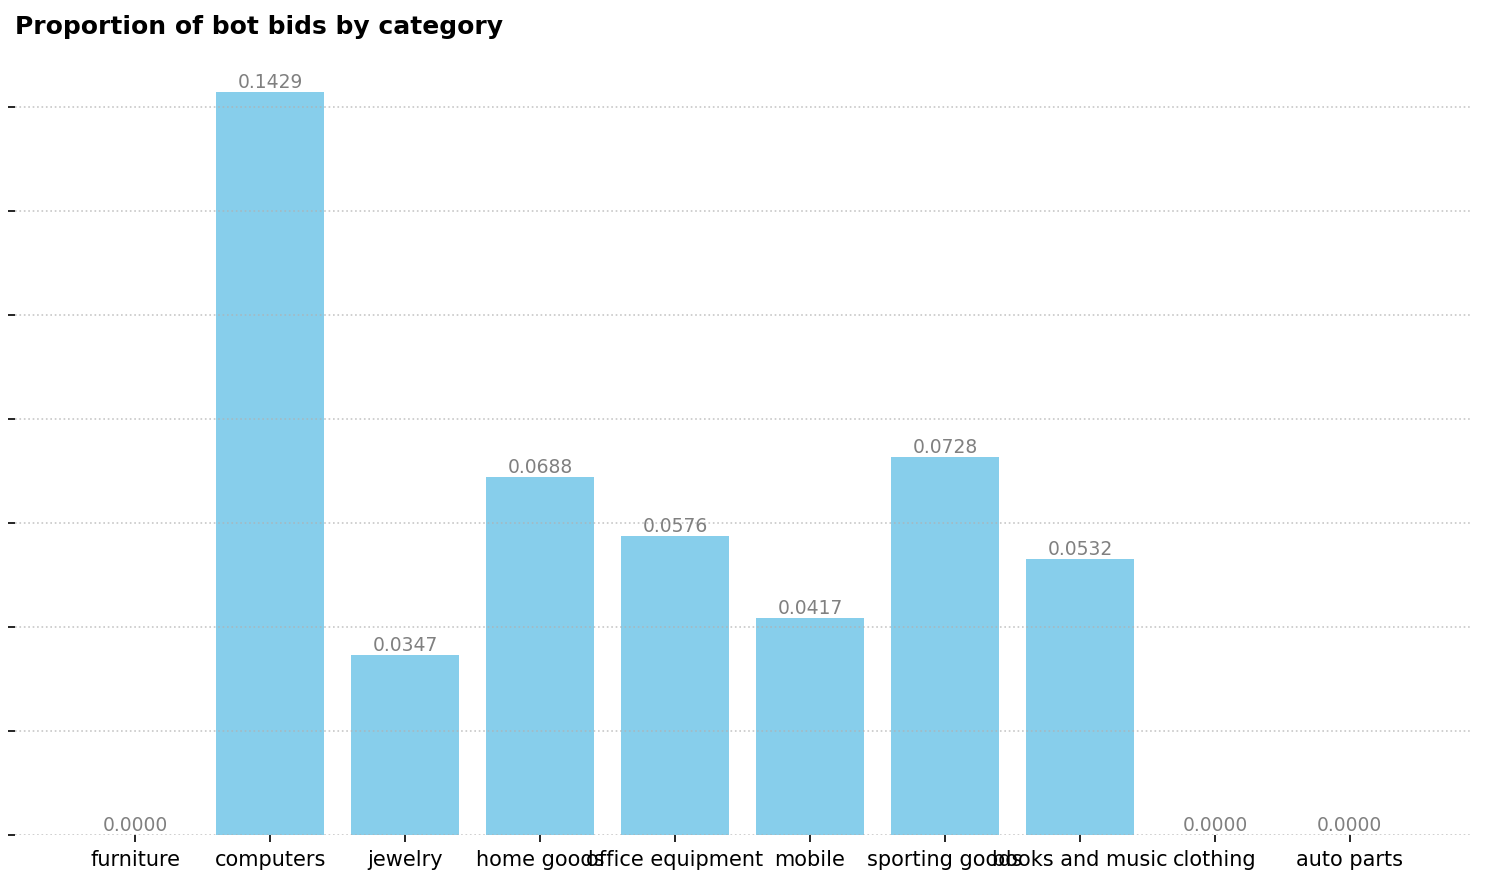

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)
ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.7, zorder=0)

bars = ax.bar(merch_out["merchandise"], merch_out["outcome"], color="skyblue", zorder=1)

for bar, value in zip(bars, merch_out["outcome"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="grey"
    )

ax.set_title("Proportion of bot bids by category", fontsize=12, fontweight="bold", pad=10, loc="left")

ax.set_xticklabels(merch_out["merchandise"])
ax.set_yticklabels([])

plt.tight_layout()
plt.show()

Seems that bots like to bid on computers, sporting goods and home goods the most, leaving furniture, auto parts and clothing to humans only. Bidding merch may be a good indicator for prediction

### Num of IPs per bidder

In [40]:
bids

bid_id,bidder_id,auction,merchandise,device,time,country,ip,url
i64,str,str,str,str,i64,str,str,str
0,"""8dac2b259fd1c6d1120e519fb1ac14…","""ewmzr""","""jewelry""","""phone0""",9759243157894736,"""us""","""69.166.231.58""","""vasstdc27m7nks3"""
1,"""668d393e858e8126275433046bbd35…","""aeqok""","""furniture""","""phone1""",9759243157894736,"""in""","""50.201.125.84""","""jmqlhflrzwuay9c"""
2,"""aa5f360084278b35d746fa6af3a7a1…","""wa00e""","""home goods""","""phone2""",9759243157894736,"""py""","""112.54.208.157""","""vasstdc27m7nks3"""
3,"""3939ac3ef7d472a59a9c5f893dd3e3…","""jefix""","""jewelry""","""phone4""",9759243157894736,"""in""","""18.99.175.133""","""vasstdc27m7nks3"""
4,"""8393c48eaf4b8fa96886edc7cf27b3…","""jefix""","""jewelry""","""phone5""",9759243157894736,"""in""","""145.138.5.37""","""vasstdc27m7nks3"""
…,…,…,…,…,…,…,…,…
7656329,"""626159dd6f2228ede002d9f9340f75…","""3e64w""","""jewelry""","""phone91""",9709222052631578,"""ru""","""140.204.227.63""","""cghhmomsaxi6pug"""
7656330,"""a318ea333ceee1ba39a49447638613…","""xn0y0""","""mobile""","""phone236""",9709222052631578,"""pl""","""24.232.159.118""","""wgggpdg2gx5pesn"""
7656331,"""f5b2bbad20d1d7ded3ed960393bec0…","""gja6c""","""sporting goods""","""phone80""",9709222052631578,"""za""","""80.237.28.246""","""5xgysg14grlersa"""


In [41]:
ip_count_per_bidder = bids.group_by("bidder_id").n_unique().select(["bidder_id", "ip"])
ip_count_per_bidder

bidder_id,ip
str,u32
"""7da6a36817cf2d8c3be218a32ab255…",20
"""182368c4fa398930423181fe51f182…",2661
"""ed5fc53d096bcf1b86c30128040e77…",170
"""a89dab37d70221a05ce82b835eb60e…",9
"""d9576f0ba8c7479eb2b26f0d15c4ab…",13
…,…
"""52399ce43b0c0aa63c6cc2a1b5fb79…",8884
"""3cff6e00ae59af6324184f22418537…",52
"""96fea49c41cd8d2294f158a8054249…",35


In [42]:
ip_count_per_bidder["ip"].shape == n_devices_per_bidder["device"].shape

True

In [43]:
ip_count_per_bidder["ip"] == n_devices_per_bidder["device"]

ip
bool
false
false
false
false
false
…
false
false
false


In [44]:
train = train.join(ip_count_per_bidder, on="bidder_id", how="left")
train

bidder_id,payment_account,address,outcome,device,auction,merchandise,ip
str,str,str,f64,u32,u32,str,u32
"""91a3c57b13234af24875c56fb7e2b2…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,14,18,"""home goods""",20
"""624f258b49e77713fc34034560f93f…","""a3d2de7675556553a5f08e4c88d2c2…","""ae87054e5a97a8f840a3991d12611f…",0.0,2,1,"""office equipment""",3
"""1c5f4fc669099bfbfac515cd26997b…","""a3d2de7675556553a5f08e4c88d2c2…","""92520288b50f03907041887884ba49…",0.0,2,4,"""sporting goods""",4
"""4bee9aba2abda51bf43d639013d6ef…","""51d80e233f7b6a7dfdee484a3c120f…","""4cb9717c8ad7e88a9a284989dd79b9…",0.0,1,1,"""books and music""",1
"""4ab12bc61c82ddd9c2d65e60555808…","""a3d2de7675556553a5f08e4c88d2c2…","""2a96c3ce94b3be921e0296097b88b5…",0.0,53,23,"""office equipment""",123
…,…,…,…,…,…,…,…
"""369515b3af4f8ca582f90271d30b14…","""a1f85275793c4a782f0a668711f41b…","""e6882cf204a9482edd042b6e31791d…",0.0,4,25,"""mobile""",5
"""f939c17ffc7c39ac9b35b69e5e7517…","""a3d2de7675556553a5f08e4c88d2c2…","""b9b03d5a127eb07aeb9163cdcf524e…",0.0,1,1,"""mobile""",1
"""c806dbb2decba0ed3c4ff5e2e60a74…","""a3d2de7675556553a5f08e4c88d2c2…","""d02c2b288b8aabd79ff47118aff41a…",0.0,2,1,"""mobile""",2


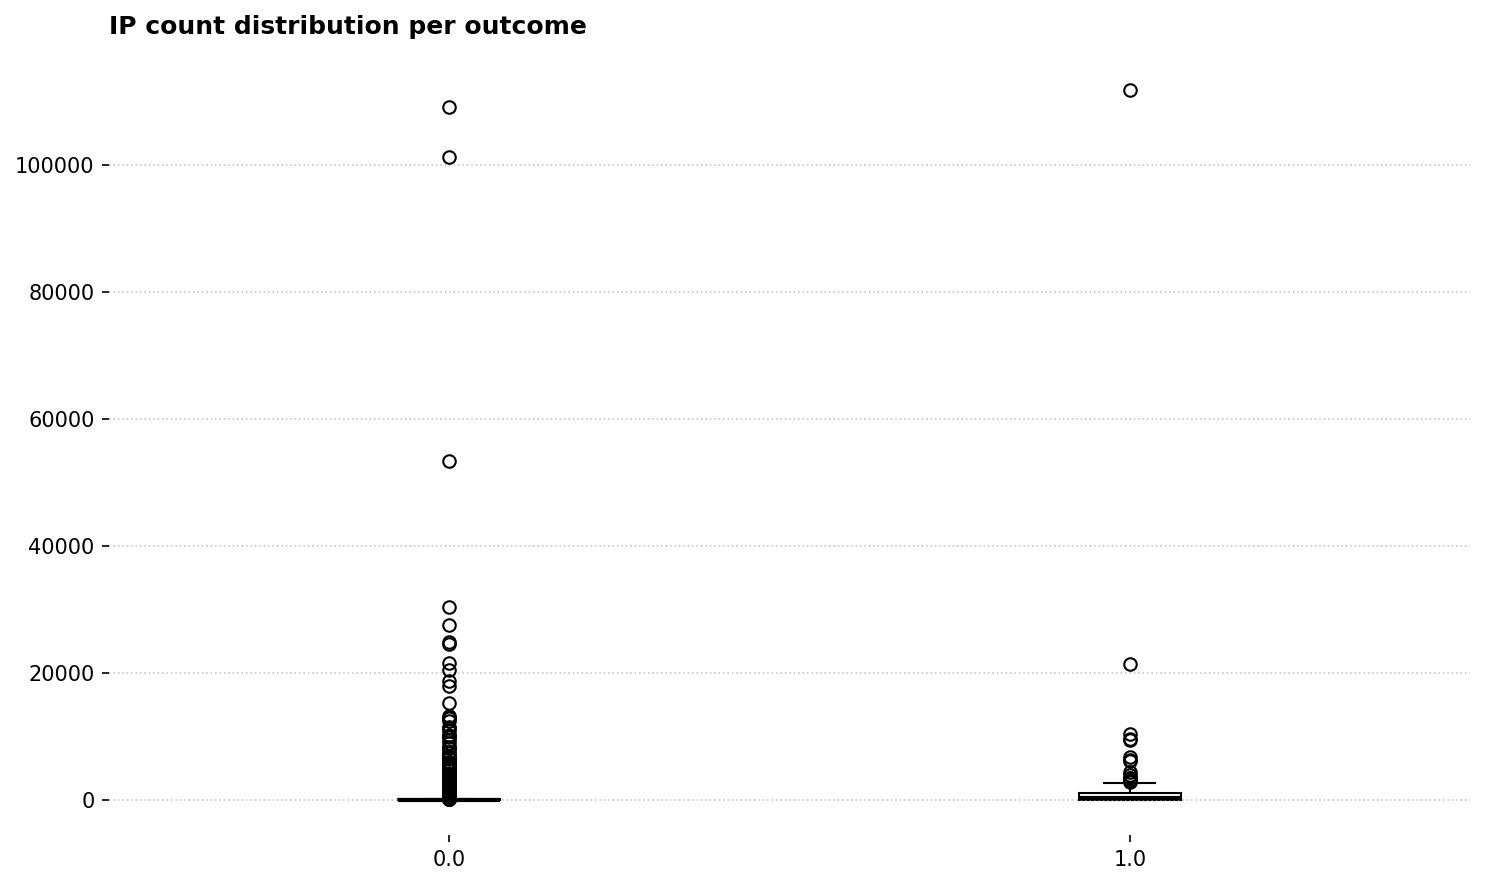

In [45]:
wide_on_outcome_ip, outcomes = pivot_table_on_column(train, "outcome", "ip")

multiple_boxplots(wide_on_outcome_ip, outcomes, "IP count distribution per outcome")

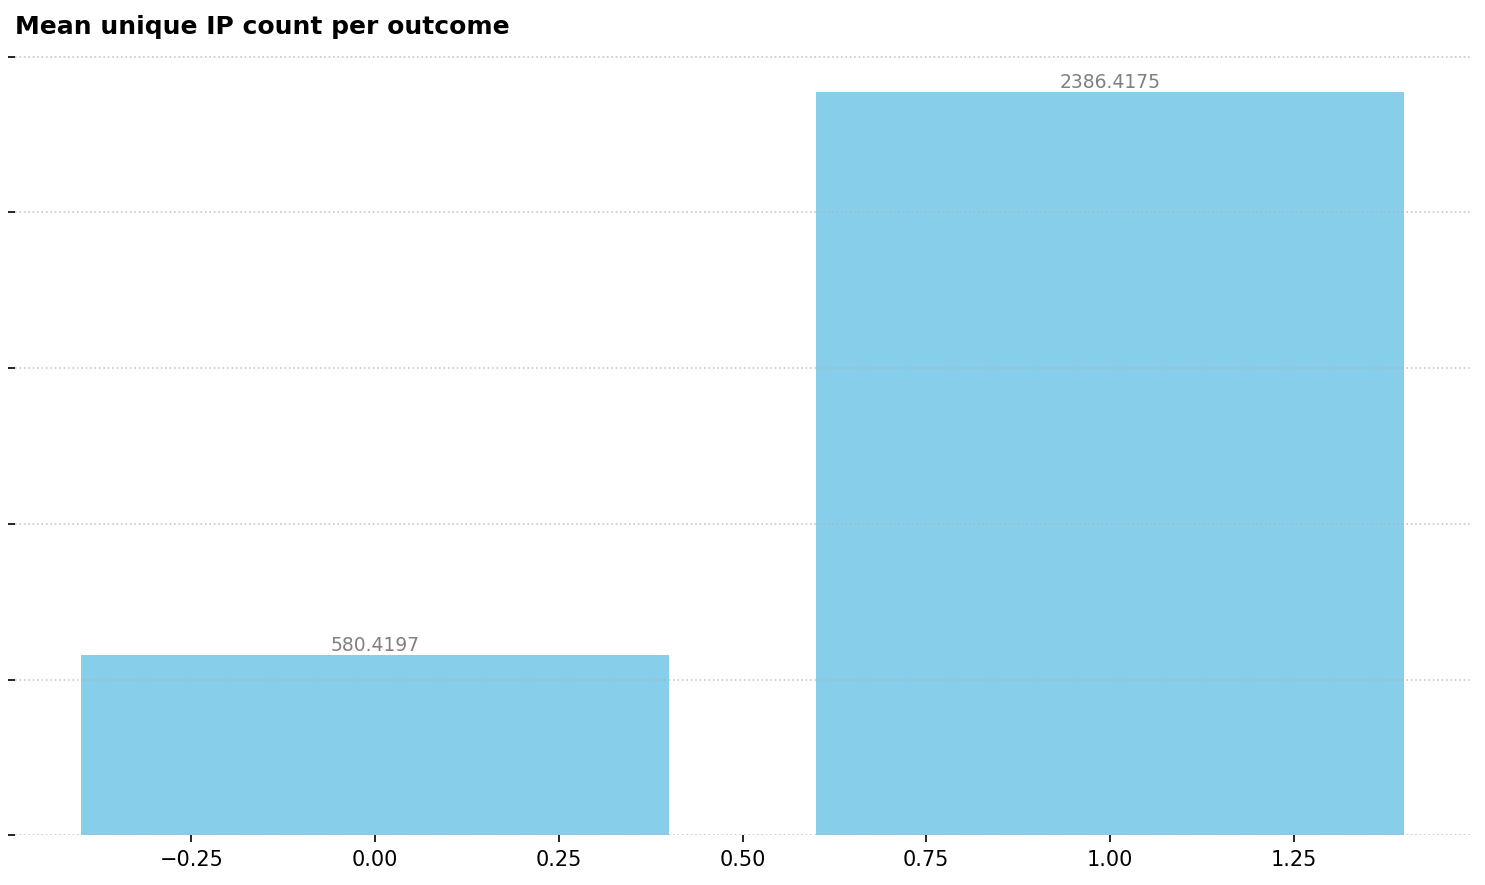

In [46]:
multiple_barplot(wide_on_outcome_ip, outcomes, "Mean unique IP count per outcome")

Outliers may pull these values much higher, but again, the mean count of IPs per robot is much much higher than for humans

### Different URLs per bidder?

In [47]:
url_count_per_bidder = bids.group_by("bidder_id").n_unique().select(["bidder_id", "url"])
url_count_per_bidder

bidder_id,url
str,u32
"""d9b19eef4f8d5df98090898bae3b02…",1
"""71d55247ed5b261503e1ff90c2a243…",32
"""2b2ee7d0ebdf910833b5cb173c5678…",1
"""c564e47acfb30c706a95537287b290…",1
"""a0aeb6de8a21a5b776f63530ed753f…",279
…,…
"""38f6a407defcefd0d238489a7d1fe2…",54
"""915ccac760c7359a446100fd1a54bb…",1436
"""2419ed502cf6b4cc6feb0a47697a04…",937


In [48]:
train = train.join(url_count_per_bidder, on="bidder_id", how="left")
train

bidder_id,payment_account,address,outcome,device,auction,merchandise,ip,url
str,str,str,f64,u32,u32,str,u32,u32
"""91a3c57b13234af24875c56fb7e2b2…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,14,18,"""home goods""",20,1
"""624f258b49e77713fc34034560f93f…","""a3d2de7675556553a5f08e4c88d2c2…","""ae87054e5a97a8f840a3991d12611f…",0.0,2,1,"""office equipment""",3,2
"""1c5f4fc669099bfbfac515cd26997b…","""a3d2de7675556553a5f08e4c88d2c2…","""92520288b50f03907041887884ba49…",0.0,2,4,"""sporting goods""",4,2
"""4bee9aba2abda51bf43d639013d6ef…","""51d80e233f7b6a7dfdee484a3c120f…","""4cb9717c8ad7e88a9a284989dd79b9…",0.0,1,1,"""books and music""",1,1
"""4ab12bc61c82ddd9c2d65e60555808…","""a3d2de7675556553a5f08e4c88d2c2…","""2a96c3ce94b3be921e0296097b88b5…",0.0,53,23,"""office equipment""",123,91
…,…,…,…,…,…,…,…,…
"""369515b3af4f8ca582f90271d30b14…","""a1f85275793c4a782f0a668711f41b…","""e6882cf204a9482edd042b6e31791d…",0.0,4,25,"""mobile""",5,2
"""f939c17ffc7c39ac9b35b69e5e7517…","""a3d2de7675556553a5f08e4c88d2c2…","""b9b03d5a127eb07aeb9163cdcf524e…",0.0,1,1,"""mobile""",1,1
"""c806dbb2decba0ed3c4ff5e2e60a74…","""a3d2de7675556553a5f08e4c88d2c2…","""d02c2b288b8aabd79ff47118aff41a…",0.0,2,1,"""mobile""",2,1


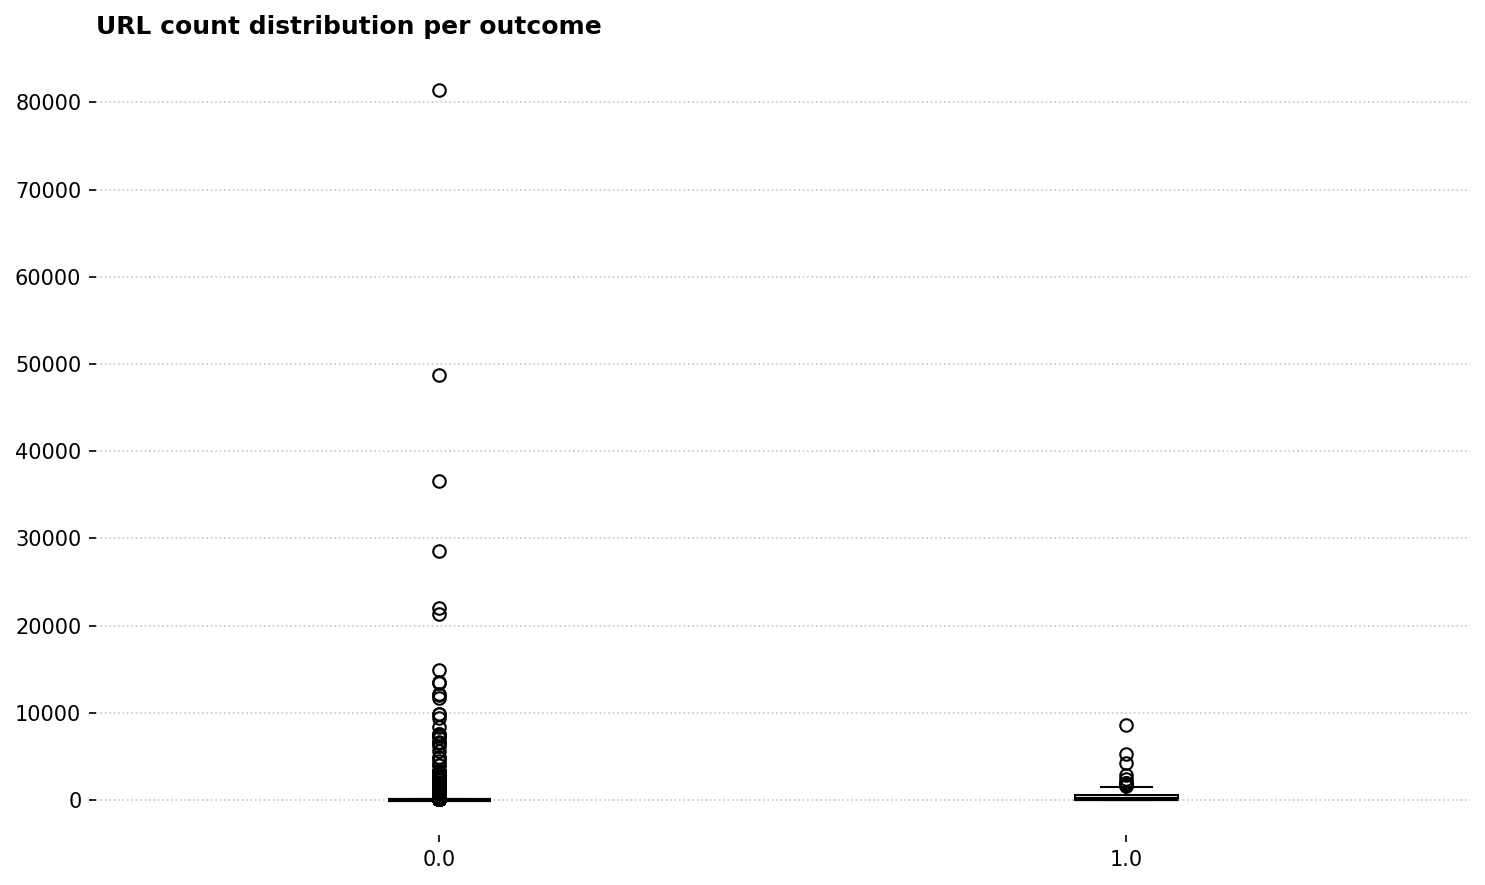

In [49]:
wide_on_outcome_url, outcomes = pivot_table_on_column(train, "outcome", "url")

multiple_boxplots(wide_on_outcome_url, outcomes, "URL count distribution per outcome")

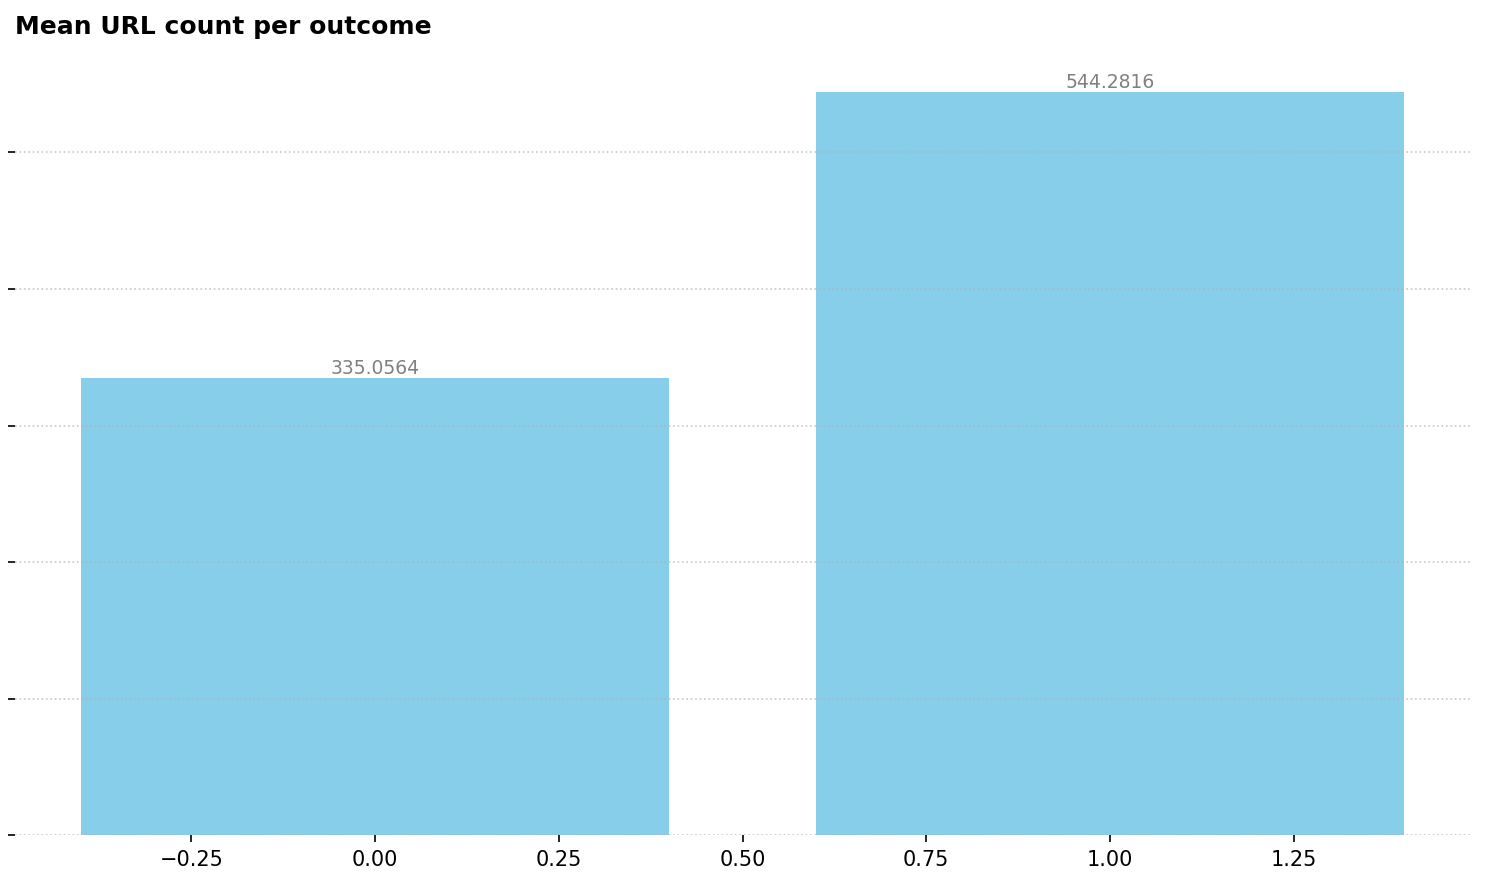

In [50]:
multiple_barplot(wide_on_outcome_url, outcomes, "Mean URL count per outcome")

Bots are redirected from many more different URLs than humans on average

### Pattern on outcome bidder country?

In [51]:
labeled_bids = bids.join(train.select(["bidder_id", "outcome"]), on="bidder_id", how="left").drop_nulls()
labeled_bids

bid_id,bidder_id,auction,merchandise,device,time,country,ip,url,outcome
i64,str,str,str,str,i64,str,str,str,f64
1,"""668d393e858e8126275433046bbd35…","""aeqok""","""furniture""","""phone1""",9759243157894736,"""in""","""50.201.125.84""","""jmqlhflrzwuay9c""",0.0
5,"""e8291466de91b0eb4e1515143c7f74…","""3vi4t""","""mobile""","""phone7""",9759243157894736,"""ru""","""91.107.221.27""","""vasstdc27m7nks3""",0.0
9,"""a58ace8b671a7531c88814bc86b2a3…","""3zpkj""","""sporting goods""","""phone4""",9759243210526315,"""za""","""123.28.123.226""","""vasstdc27m7nks3""",0.0
10,"""a58ace8b671a7531c88814bc86b2a3…","""z6j8b""","""sporting goods""","""phone10""",9759243210526315,"""ng""","""209.80.85.101""","""adgjz71s3p2oiau""",0.0
13,"""7e34a26c4c339e875997f4b9239d2b…","""nbx39""","""mobile""","""phone13""",9759243263157894,"""in""","""143.183.225.33""","""e5i17pk9wygxewv""",0.0
…,…,…,…,…,…,…,…,…,…
7656321,"""f5b2bbad20d1d7ded3ed960393bec0…","""gja6c""","""sporting goods""","""phone1""",9709222000000000,"""za""","""231.197.103.67""","""pqzlexr3qrl6gmx""",0.0
7656323,"""9655ccc7c0c193f1549475f02c54dc…","""1f9t0""","""sporting goods""","""phone718""",9709222000000000,"""us""","""199.76.204.89""","""vasstdc27m7nks3""",1.0
7656325,"""93e3c34171ab65e0b031dc67461e48…","""jmny0""","""jewelry""","""phone892""",9709222052631578,"""id""","""136.144.47.247""","""36phop3q8vduhf5""",0.0


In [52]:
# labeled_bids.group_by("country").count()#.select(["country", "outcome"])
country_stats = (
    labeled_bids
    .group_by("country")
    .agg([
        pl.count().alias("total_bids"),
        pl.sum("outcome").alias("bot_bids")  # sum of 1s == number of bot bids
    ])
    .with_columns([
        (pl.col("bot_bids") / pl.col("total_bids")).alias("bot_proportion")
    ])
    .sort("bot_proportion", descending=True)
)

country_stats.filter(pl.col("bot_proportion") == 1)

/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_32161/1336918007.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias("total_bids"),


country,total_bids,bot_bids,bot_proportion
str,u32,f64,f64
"""gp""",2,2.0,1.0
"""aw""",7,7.0,1.0
"""tc""",1,1.0,1.0
"""gi""",1,1.0,1.0
"""vi""",8,8.0,1.0
"""nc""",11,11.0,1.0
"""an""",1,1.0,1.0


7 countries off of all IPs are all bots. Let's find out if bidders can come from more than one country. If so, we can discover if the most occurring country per user is related to the outcome. Then we can use it to predict

In [53]:
bids.group_by("bidder_id").n_unique().select(["bidder_id", "country"])

bidder_id,country
str,u32
"""67336e0b5f4cf7b1bed98e83562943…",5
"""a6f994251abda6687ada2e9de52bdd…",1
"""a4e513ea65fb440da16a2fb9241d24…",2
"""bcc952d4faa6dc0a093bd525dbda1a…",1
"""9dabf23db597c70a47d5be43899afe…",1
…,…
"""e4b0a00720e247e4038e2d687499bd…",2
"""e8a33f6b37e8f53cef5626387ba675…",1
"""ae0dc05e48d0f1e3ad33f37b4400bd…",1


In [54]:
country_counts = (
    bids
    .group_by(["bidder_id", "country"])
    .agg(pl.count().alias("country_count"))
)

# Step 2: Sort by count descending, so the top one per bidder is first
# Step 3: Use `group_by` + `first()` to pick the top country per bidder
max_country_per_bidder = (
    country_counts
    .sort(["bidder_id", "country_count"], descending=[False, True])
    .group_by("bidder_id")
    .agg([
        pl.first("country").alias("most_frequent_country")
    ])
)

max_country_per_bidder

/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_32161/2261247118.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  .agg(pl.count().alias("country_count"))


bidder_id,most_frequent_country
str,str
"""001068c415025a009fee375a12cff4…","""bn"""
"""002d229ffb247009810828f648afc2…","""sg"""
"""0030a2dd87ad2733e0873062e4f839…","""ir"""
"""003180b29c6a5f8f1d84a6b7b6f7be…","""id"""
"""00486a11dff552c4bd7696265724ff…","""ng"""
…,…
"""ffbc0fdfbf19a8a9116b68714138f2…","""in"""
"""ffc4e2dd2cc08249f299cab46ecbfa…","""ng"""
"""ffd29eb307a4c54610dd2d3d212bf3…","""es"""


In [55]:
train = train.join(max_country_per_bidder, on="bidder_id", how="left")
train

bidder_id,payment_account,address,outcome,device,auction,merchandise,ip,url,most_frequent_country
str,str,str,f64,u32,u32,str,u32,u32,str
"""91a3c57b13234af24875c56fb7e2b2…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,14,18,"""home goods""",20,1,"""ke"""
"""624f258b49e77713fc34034560f93f…","""a3d2de7675556553a5f08e4c88d2c2…","""ae87054e5a97a8f840a3991d12611f…",0.0,2,1,"""office equipment""",3,2,"""id"""
"""1c5f4fc669099bfbfac515cd26997b…","""a3d2de7675556553a5f08e4c88d2c2…","""92520288b50f03907041887884ba49…",0.0,2,4,"""sporting goods""",4,2,"""id"""
"""4bee9aba2abda51bf43d639013d6ef…","""51d80e233f7b6a7dfdee484a3c120f…","""4cb9717c8ad7e88a9a284989dd79b9…",0.0,1,1,"""books and music""",1,1,"""my"""
"""4ab12bc61c82ddd9c2d65e60555808…","""a3d2de7675556553a5f08e4c88d2c2…","""2a96c3ce94b3be921e0296097b88b5…",0.0,53,23,"""office equipment""",123,91,"""in"""
…,…,…,…,…,…,…,…,…,…
"""369515b3af4f8ca582f90271d30b14…","""a1f85275793c4a782f0a668711f41b…","""e6882cf204a9482edd042b6e31791d…",0.0,4,25,"""mobile""",5,2,"""uk"""
"""f939c17ffc7c39ac9b35b69e5e7517…","""a3d2de7675556553a5f08e4c88d2c2…","""b9b03d5a127eb07aeb9163cdcf524e…",0.0,1,1,"""mobile""",1,1,"""ua"""
"""c806dbb2decba0ed3c4ff5e2e60a74…","""a3d2de7675556553a5f08e4c88d2c2…","""d02c2b288b8aabd79ff47118aff41a…",0.0,2,1,"""mobile""",2,1,"""id"""


In [56]:
train.filter(pl.col("outcome") == 1)

bidder_id,payment_account,address,outcome,device,auction,merchandise,ip,url,most_frequent_country
str,str,str,f64,u32,u32,str,u32,u32,str
"""5354c02817e47f28e60e44a40ca5e4…","""1862ef3b7965993cc975a1161010e8…","""58e5dc4d38d886f6c7abf0c264a51c…",1.0,51,18,"""mobile""",13,1,"""id"""
"""9434778d2268f1fa2a8ede48c0cd05…","""ee3295c7b31a1e9116ebf0cf2df68e…","""627fe7481f01372c02333477471cb2…",1.0,408,269,"""jewelry""",3441,1909,"""in"""
"""aabc211b4cf4d29e4ac7e7e3613716…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",1.0,24,127,"""mobile""",358,5,"""za"""
"""68d468e15e0de0bab9694cdca8e799…","""a3d2de7675556553a5f08e4c88d2c2…","""767150cd5a97ed796bfc58456f5500…",1.0,1,26,"""office equipment""",8,7,"""au"""
"""1cbd9081de4481ada66f1853737f76…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",1.0,4,107,"""computers""",836,4,"""mx"""
…,…,…,…,…,…,…,…,…,…
"""458c8c4e10e5c1b29e3fbe5ee56d46…","""97ee873207ff7c57e70c50637c93c1…","""480aca092e44d3e23a015e51d8e7da…",1.0,166,103,"""sporting goods""",413,844,"""ca"""
"""022ac3a7ce986049d9a4bede83ccf9…","""57aec2c76d2db80cf61c2543d15ef9…","""c57c64adcc43ce50d99f184d87981d…",1.0,18,85,"""home goods""",32,2,"""us"""
"""6c11cc7744fb52a632306ca8bf966c…","""0875307e1731af94b3b64725ad0deb…","""a10741281aa478c1f3ce0c965debb3…",1.0,164,100,"""home goods""",414,363,"""id"""


### Time delta between bids

In [57]:
bids = bids.sort(["bidder_id", "time"], descending=False).with_columns(
    pl.col("time").diff().over("bidder_id").fill_null(0).alias("diff_last_bid")
)
bids

bid_id,bidder_id,auction,merchandise,device,time,country,ip,url,diff_last_bid
i64,str,str,str,str,i64,str,str,str,i64
7179832,"""001068c415025a009fee375a12cff4…","""4ifac""","""jewelry""","""phone561""",9706345052631578,"""bn""","""139.226.147.115""","""vasstdc27m7nks3""",0
1281292,"""002d229ffb247009810828f648afc2…","""2tdw2""","""mobile""","""phone640""",9766744105263157,"""sg""","""37.40.254.131""","""vasstdc27m7nks3""",0
1281311,"""002d229ffb247009810828f648afc2…","""2tdw2""","""mobile""","""phone219""",9766744210526315,"""sg""","""37.40.254.131""","""vasstdc27m7nks3""",105263158
6805028,"""0030a2dd87ad2733e0873062e4f839…","""obbny""","""mobile""","""phone313""",9704553947368421,"""ir""","""21.67.17.162""","""vnw40k8zzokijsv""",0
3967330,"""003180b29c6a5f8f1d84a6b7b6f7be…","""obbny""","""mobile""","""phone420""",9640018631578947,"""id""","""44.241.8.179""","""sj4jidex850loas""",0
…,…,…,…,…,…,…,…,…,…
2336021,"""ffd62646d600b759a985d45918bd6f…","""dwy5m""","""mobile""","""phone293""",9772802947368421,"""id""","""214.13.99.0""","""zkb9nv4gtdm2vrw""",5631578948
2337626,"""ffd62646d600b759a985d45918bd6f…","""kh2ef""","""mobile""","""phone195""",9772811421052631,"""id""","""144.253.142.62""","""vasstdc27m7nks3""",8473684210
2344645,"""ffd62646d600b759a985d45918bd6f…","""wc5b0""","""mobile""","""phone153""",9772850052631578,"""id""","""166.67.25.123""","""l69hkdm98yfwmu0""",38631578947


Filling null values with 0 may pull the mean downwards when taking the mean. Alternatively, leaving the time value will deifnitely pull the mean upwards. The tradeoff is that if a lower mean diff is correlated with being a bot, 0 is the lowest possible diff. Someone that only bid once may be confused with a bot by linear models. A tree might learn this relationship non-linearly. I prefer this over the alternative of the time value itself which will for sure pull all means upwards 

In [58]:
mean_time_diff_bids = bids.group_by("bidder_id").agg(
    pl.col("diff_last_bid").mean().alias("mean_diff_time_bids")
)
mean_time_diff_bids

bidder_id,mean_diff_time_bids
str,f64
"""001068c415025a009fee375a12cff4…",0.0
"""002d229ffb247009810828f648afc2…",5.2631579e7
"""0030a2dd87ad2733e0873062e4f839…",0.0
"""003180b29c6a5f8f1d84a6b7b6f7be…",2.1985e13
"""00486a11dff552c4bd7696265724ff…",3.8175e12
…,…
"""ffbc0fdfbf19a8a9116b68714138f2…",5.4399e8
"""ffc4e2dd2cc08249f299cab46ecbfa…",3.4329e12
"""ffd29eb307a4c54610dd2d3d212bf3…",0.0


In [59]:
train = train.join(mean_time_diff_bids, on="bidder_id", how="left")
train

bidder_id,payment_account,address,outcome,device,auction,merchandise,ip,url,most_frequent_country,mean_diff_time_bids
str,str,str,f64,u32,u32,str,u32,u32,str,f64
"""91a3c57b13234af24875c56fb7e2b2…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,14,18,"""home goods""",20,1,"""ke""",5.4732e11
"""624f258b49e77713fc34034560f93f…","""a3d2de7675556553a5f08e4c88d2c2…","""ae87054e5a97a8f840a3991d12611f…",0.0,2,1,"""office equipment""",3,2,"""id""",2.1557e12
"""1c5f4fc669099bfbfac515cd26997b…","""a3d2de7675556553a5f08e4c88d2c2…","""92520288b50f03907041887884ba49…",0.0,2,4,"""sporting goods""",4,2,"""id""",1.7842e12
"""4bee9aba2abda51bf43d639013d6ef…","""51d80e233f7b6a7dfdee484a3c120f…","""4cb9717c8ad7e88a9a284989dd79b9…",0.0,1,1,"""books and music""",1,1,"""my""",0.0
"""4ab12bc61c82ddd9c2d65e60555808…","""a3d2de7675556553a5f08e4c88d2c2…","""2a96c3ce94b3be921e0296097b88b5…",0.0,53,23,"""office equipment""",123,91,"""in""",7.7277e10
…,…,…,…,…,…,…,…,…,…,…
"""369515b3af4f8ca582f90271d30b14…","""a1f85275793c4a782f0a668711f41b…","""e6882cf204a9482edd042b6e31791d…",0.0,4,25,"""mobile""",5,2,"""uk""",2.0409e12
"""f939c17ffc7c39ac9b35b69e5e7517…","""a3d2de7675556553a5f08e4c88d2c2…","""b9b03d5a127eb07aeb9163cdcf524e…",0.0,1,1,"""mobile""",1,1,"""ua""",0.0
"""c806dbb2decba0ed3c4ff5e2e60a74…","""a3d2de7675556553a5f08e4c88d2c2…","""d02c2b288b8aabd79ff47118aff41a…",0.0,2,1,"""mobile""",2,1,"""id""",4.8992e12


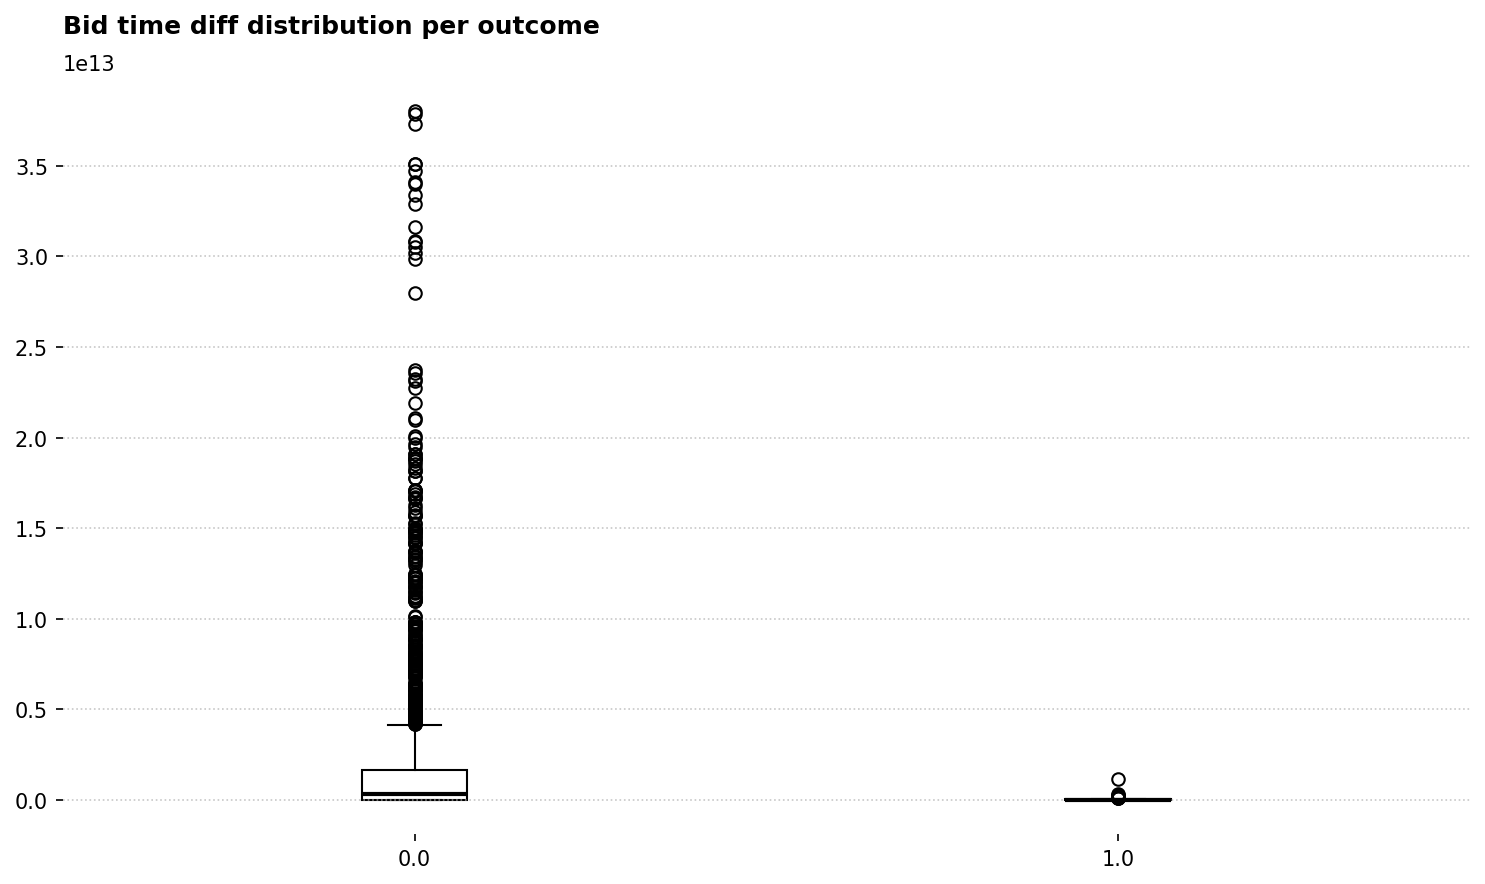

In [60]:
wide_on_outcome_time_diff, outcomes = pivot_table_on_column(train, "outcome", "mean_diff_time_bids")

multiple_boxplots(wide_on_outcome_time_diff, outcomes, "Bid time diff distribution per outcome")

It is evident despite all outliers that the humans' mean diff is located higher than the bots'

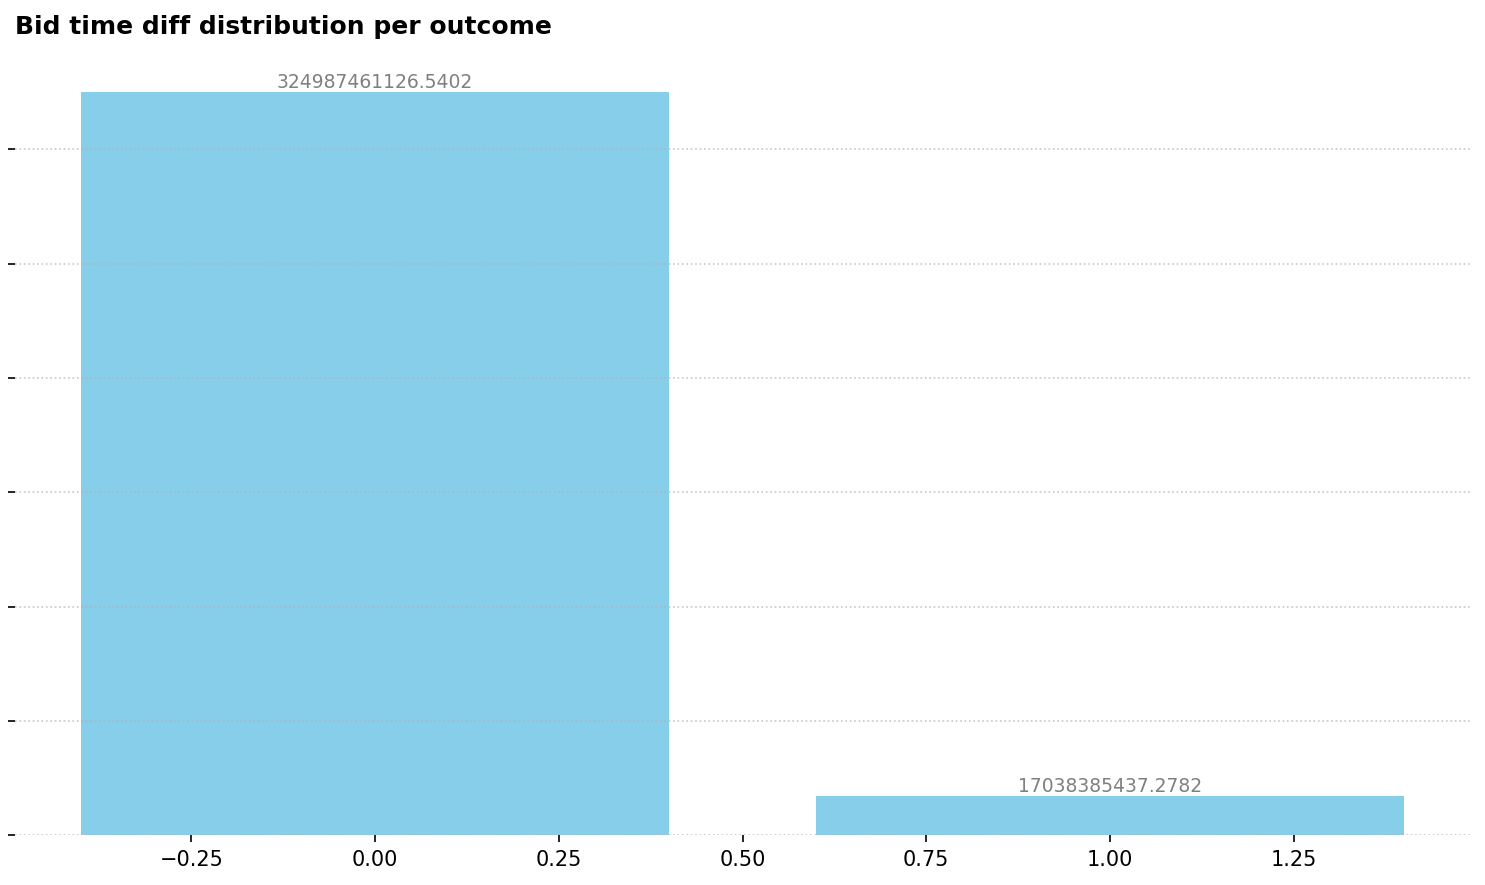

In [81]:
multiple_barplot(wide_on_outcome_time_diff, outcomes, "Bid time diff distribution per outcome", metric="median")

This might be the strongest predictive variable regarding whether the user is a bot or a human

In [62]:
bids

bid_id,bidder_id,auction,merchandise,device,time,country,ip,url,diff_last_bid
i64,str,str,str,str,i64,str,str,str,i64
7179832,"""001068c415025a009fee375a12cff4…","""4ifac""","""jewelry""","""phone561""",9706345052631578,"""bn""","""139.226.147.115""","""vasstdc27m7nks3""",0
1281292,"""002d229ffb247009810828f648afc2…","""2tdw2""","""mobile""","""phone640""",9766744105263157,"""sg""","""37.40.254.131""","""vasstdc27m7nks3""",0
1281311,"""002d229ffb247009810828f648afc2…","""2tdw2""","""mobile""","""phone219""",9766744210526315,"""sg""","""37.40.254.131""","""vasstdc27m7nks3""",105263158
6805028,"""0030a2dd87ad2733e0873062e4f839…","""obbny""","""mobile""","""phone313""",9704553947368421,"""ir""","""21.67.17.162""","""vnw40k8zzokijsv""",0
3967330,"""003180b29c6a5f8f1d84a6b7b6f7be…","""obbny""","""mobile""","""phone420""",9640018631578947,"""id""","""44.241.8.179""","""sj4jidex850loas""",0
…,…,…,…,…,…,…,…,…,…
2336021,"""ffd62646d600b759a985d45918bd6f…","""dwy5m""","""mobile""","""phone293""",9772802947368421,"""id""","""214.13.99.0""","""zkb9nv4gtdm2vrw""",5631578948
2337626,"""ffd62646d600b759a985d45918bd6f…","""kh2ef""","""mobile""","""phone195""",9772811421052631,"""id""","""144.253.142.62""","""vasstdc27m7nks3""",8473684210
2344645,"""ffd62646d600b759a985d45918bd6f…","""wc5b0""","""mobile""","""phone153""",9772850052631578,"""id""","""166.67.25.123""","""l69hkdm98yfwmu0""",38631578947


### Number of bids per bidder

In [63]:
bids

bid_id,bidder_id,auction,merchandise,device,time,country,ip,url,diff_last_bid
i64,str,str,str,str,i64,str,str,str,i64
7179832,"""001068c415025a009fee375a12cff4…","""4ifac""","""jewelry""","""phone561""",9706345052631578,"""bn""","""139.226.147.115""","""vasstdc27m7nks3""",0
1281292,"""002d229ffb247009810828f648afc2…","""2tdw2""","""mobile""","""phone640""",9766744105263157,"""sg""","""37.40.254.131""","""vasstdc27m7nks3""",0
1281311,"""002d229ffb247009810828f648afc2…","""2tdw2""","""mobile""","""phone219""",9766744210526315,"""sg""","""37.40.254.131""","""vasstdc27m7nks3""",105263158
6805028,"""0030a2dd87ad2733e0873062e4f839…","""obbny""","""mobile""","""phone313""",9704553947368421,"""ir""","""21.67.17.162""","""vnw40k8zzokijsv""",0
3967330,"""003180b29c6a5f8f1d84a6b7b6f7be…","""obbny""","""mobile""","""phone420""",9640018631578947,"""id""","""44.241.8.179""","""sj4jidex850loas""",0
…,…,…,…,…,…,…,…,…,…
2336021,"""ffd62646d600b759a985d45918bd6f…","""dwy5m""","""mobile""","""phone293""",9772802947368421,"""id""","""214.13.99.0""","""zkb9nv4gtdm2vrw""",5631578948
2337626,"""ffd62646d600b759a985d45918bd6f…","""kh2ef""","""mobile""","""phone195""",9772811421052631,"""id""","""144.253.142.62""","""vasstdc27m7nks3""",8473684210
2344645,"""ffd62646d600b759a985d45918bd6f…","""wc5b0""","""mobile""","""phone153""",9772850052631578,"""id""","""166.67.25.123""","""l69hkdm98yfwmu0""",38631578947


In [64]:
bid_counts = bids.group_by("bidder_id").agg(
    pl.n_unique("bid_id").alias("bid_count")
)
bids = bids.join(bid_counts, on="bidder_id", how="left")
bids

bid_id,bidder_id,auction,merchandise,device,time,country,ip,url,diff_last_bid,bid_count
i64,str,str,str,str,i64,str,str,str,i64,u32
7179832,"""001068c415025a009fee375a12cff4…","""4ifac""","""jewelry""","""phone561""",9706345052631578,"""bn""","""139.226.147.115""","""vasstdc27m7nks3""",0,1
1281292,"""002d229ffb247009810828f648afc2…","""2tdw2""","""mobile""","""phone640""",9766744105263157,"""sg""","""37.40.254.131""","""vasstdc27m7nks3""",0,2
1281311,"""002d229ffb247009810828f648afc2…","""2tdw2""","""mobile""","""phone219""",9766744210526315,"""sg""","""37.40.254.131""","""vasstdc27m7nks3""",105263158,2
6805028,"""0030a2dd87ad2733e0873062e4f839…","""obbny""","""mobile""","""phone313""",9704553947368421,"""ir""","""21.67.17.162""","""vnw40k8zzokijsv""",0,1
3967330,"""003180b29c6a5f8f1d84a6b7b6f7be…","""obbny""","""mobile""","""phone420""",9640018631578947,"""id""","""44.241.8.179""","""sj4jidex850loas""",0,3
…,…,…,…,…,…,…,…,…,…,…
2336021,"""ffd62646d600b759a985d45918bd6f…","""dwy5m""","""mobile""","""phone293""",9772802947368421,"""id""","""214.13.99.0""","""zkb9nv4gtdm2vrw""",5631578948,664
2337626,"""ffd62646d600b759a985d45918bd6f…","""kh2ef""","""mobile""","""phone195""",9772811421052631,"""id""","""144.253.142.62""","""vasstdc27m7nks3""",8473684210,664
2344645,"""ffd62646d600b759a985d45918bd6f…","""wc5b0""","""mobile""","""phone153""",9772850052631578,"""id""","""166.67.25.123""","""l69hkdm98yfwmu0""",38631578947,664


In [65]:
train = train.join(bid_counts, on="bidder_id", how="left")
train

bidder_id,payment_account,address,outcome,device,auction,merchandise,ip,url,most_frequent_country,mean_diff_time_bids,bid_count
str,str,str,f64,u32,u32,str,u32,u32,str,f64,u32
"""91a3c57b13234af24875c56fb7e2b2…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,14,18,"""home goods""",20,1,"""ke""",5.4732e11,24
"""624f258b49e77713fc34034560f93f…","""a3d2de7675556553a5f08e4c88d2c2…","""ae87054e5a97a8f840a3991d12611f…",0.0,2,1,"""office equipment""",3,2,"""id""",2.1557e12,3
"""1c5f4fc669099bfbfac515cd26997b…","""a3d2de7675556553a5f08e4c88d2c2…","""92520288b50f03907041887884ba49…",0.0,2,4,"""sporting goods""",4,2,"""id""",1.7842e12,4
"""4bee9aba2abda51bf43d639013d6ef…","""51d80e233f7b6a7dfdee484a3c120f…","""4cb9717c8ad7e88a9a284989dd79b9…",0.0,1,1,"""books and music""",1,1,"""my""",0.0,1
"""4ab12bc61c82ddd9c2d65e60555808…","""a3d2de7675556553a5f08e4c88d2c2…","""2a96c3ce94b3be921e0296097b88b5…",0.0,53,23,"""office equipment""",123,91,"""in""",7.7277e10,155
…,…,…,…,…,…,…,…,…,…,…,…
"""369515b3af4f8ca582f90271d30b14…","""a1f85275793c4a782f0a668711f41b…","""e6882cf204a9482edd042b6e31791d…",0.0,4,25,"""mobile""",5,2,"""uk""",2.0409e12,36
"""f939c17ffc7c39ac9b35b69e5e7517…","""a3d2de7675556553a5f08e4c88d2c2…","""b9b03d5a127eb07aeb9163cdcf524e…",0.0,1,1,"""mobile""",1,1,"""ua""",0.0,1
"""c806dbb2decba0ed3c4ff5e2e60a74…","""a3d2de7675556553a5f08e4c88d2c2…","""d02c2b288b8aabd79ff47118aff41a…",0.0,2,1,"""mobile""",2,1,"""id""",4.8992e12,2


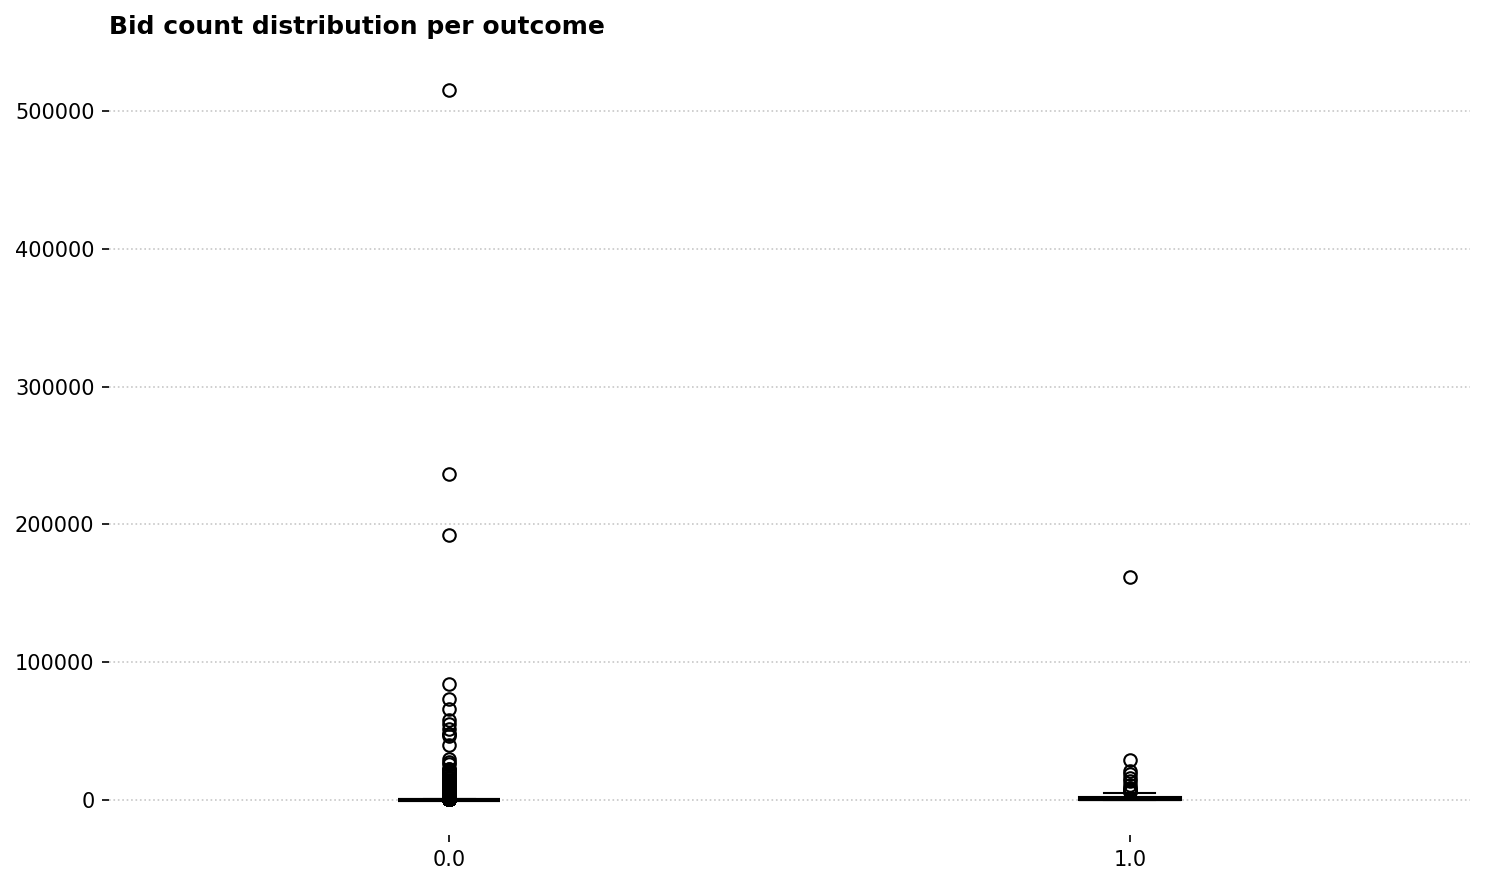

In [66]:
wide_on_outcome_bid_count, outcomes = pivot_table_on_column(train, "outcome", "bid_count")

multiple_boxplots(wide_on_outcome_bid_count, outcomes, "Bid count distribution per outcome")

Looks like someone is addicted...

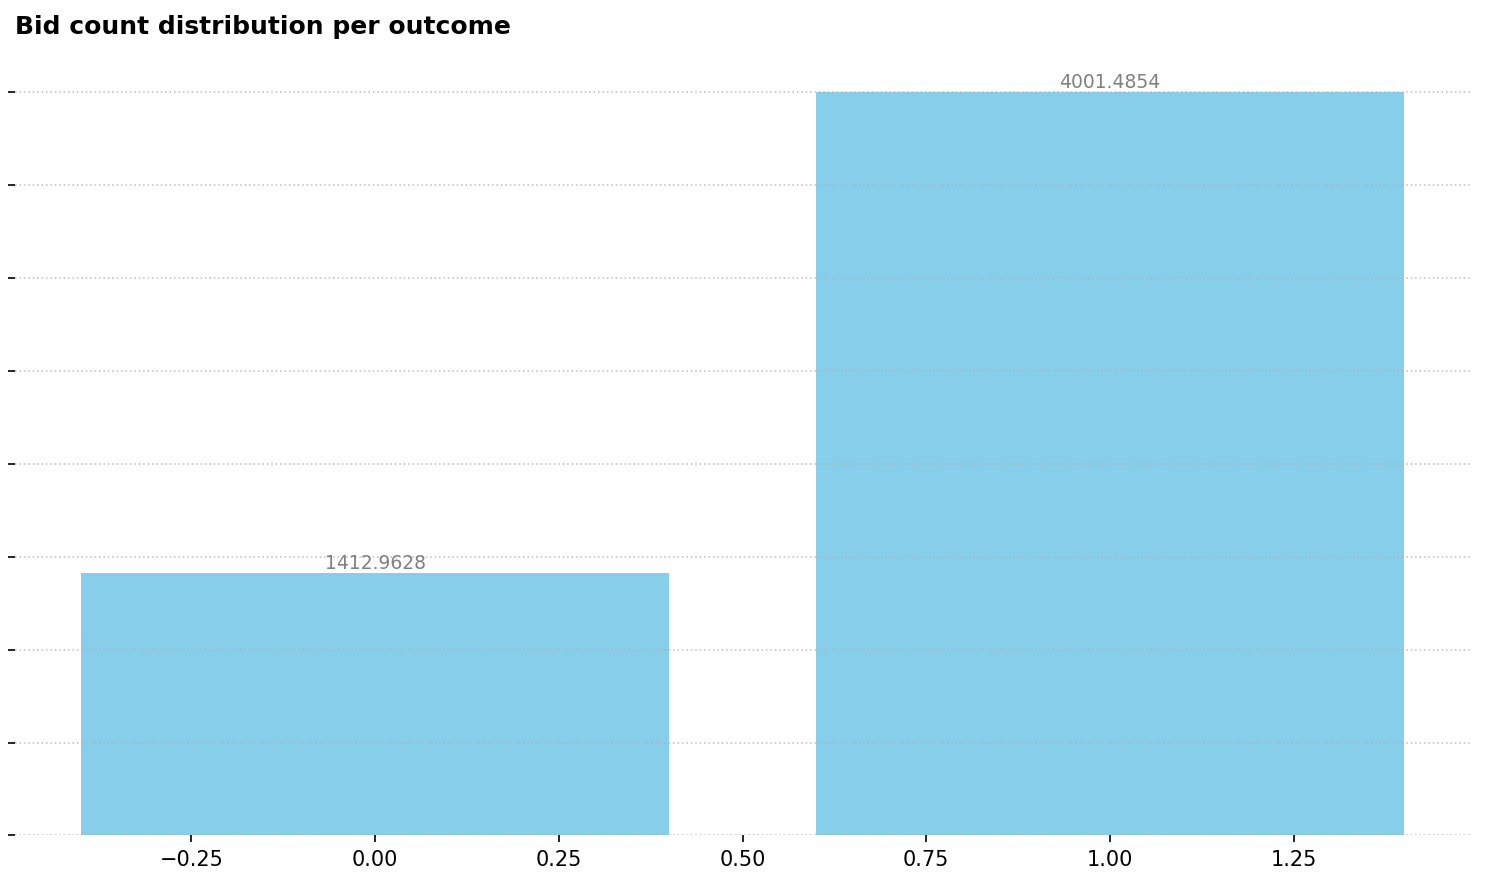

In [67]:
multiple_barplot(wide_on_outcome_bid_count, outcomes, "Bid count distribution per outcome")

Again, the mean bid count is that much higher for bots. We can't visualize the distribution because there are so many outliers for both of them. If we could we would likely see the box for the bots having a higher upper fence

### Mean/median time between bidding on different auctions

In [83]:
bids.sort(["bidder_id", "time"])

bid_id,bidder_id,auction,merchandise,device,time,country,ip,url,diff_last_bid,bid_count
i64,str,str,str,str,i64,str,str,str,i64,u32
7179832,"""001068c415025a009fee375a12cff4…","""4ifac""","""jewelry""","""phone561""",9706345052631578,"""bn""","""139.226.147.115""","""vasstdc27m7nks3""",0,1
1281292,"""002d229ffb247009810828f648afc2…","""2tdw2""","""mobile""","""phone640""",9766744105263157,"""sg""","""37.40.254.131""","""vasstdc27m7nks3""",0,2
1281311,"""002d229ffb247009810828f648afc2…","""2tdw2""","""mobile""","""phone219""",9766744210526315,"""sg""","""37.40.254.131""","""vasstdc27m7nks3""",105263158,2
6805028,"""0030a2dd87ad2733e0873062e4f839…","""obbny""","""mobile""","""phone313""",9704553947368421,"""ir""","""21.67.17.162""","""vnw40k8zzokijsv""",0,1
3967330,"""003180b29c6a5f8f1d84a6b7b6f7be…","""obbny""","""mobile""","""phone420""",9640018631578947,"""id""","""44.241.8.179""","""sj4jidex850loas""",0,3
…,…,…,…,…,…,…,…,…,…,…
2336021,"""ffd62646d600b759a985d45918bd6f…","""dwy5m""","""mobile""","""phone293""",9772802947368421,"""id""","""214.13.99.0""","""zkb9nv4gtdm2vrw""",5631578948,664
2337626,"""ffd62646d600b759a985d45918bd6f…","""kh2ef""","""mobile""","""phone195""",9772811421052631,"""id""","""144.253.142.62""","""vasstdc27m7nks3""",8473684210,664
2344645,"""ffd62646d600b759a985d45918bd6f…","""wc5b0""","""mobile""","""phone153""",9772850052631578,"""id""","""166.67.25.123""","""l69hkdm98yfwmu0""",38631578947,664


### Mean/median time between switching IPs

### Handling missing values

In [68]:
train

bidder_id,payment_account,address,outcome,device,auction,merchandise,ip,url,most_frequent_country,mean_diff_time_bids,bid_count
str,str,str,f64,u32,u32,str,u32,u32,str,f64,u32
"""91a3c57b13234af24875c56fb7e2b2…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,14,18,"""home goods""",20,1,"""ke""",5.4732e11,24
"""624f258b49e77713fc34034560f93f…","""a3d2de7675556553a5f08e4c88d2c2…","""ae87054e5a97a8f840a3991d12611f…",0.0,2,1,"""office equipment""",3,2,"""id""",2.1557e12,3
"""1c5f4fc669099bfbfac515cd26997b…","""a3d2de7675556553a5f08e4c88d2c2…","""92520288b50f03907041887884ba49…",0.0,2,4,"""sporting goods""",4,2,"""id""",1.7842e12,4
"""4bee9aba2abda51bf43d639013d6ef…","""51d80e233f7b6a7dfdee484a3c120f…","""4cb9717c8ad7e88a9a284989dd79b9…",0.0,1,1,"""books and music""",1,1,"""my""",0.0,1
"""4ab12bc61c82ddd9c2d65e60555808…","""a3d2de7675556553a5f08e4c88d2c2…","""2a96c3ce94b3be921e0296097b88b5…",0.0,53,23,"""office equipment""",123,91,"""in""",7.7277e10,155
…,…,…,…,…,…,…,…,…,…,…,…
"""369515b3af4f8ca582f90271d30b14…","""a1f85275793c4a782f0a668711f41b…","""e6882cf204a9482edd042b6e31791d…",0.0,4,25,"""mobile""",5,2,"""uk""",2.0409e12,36
"""f939c17ffc7c39ac9b35b69e5e7517…","""a3d2de7675556553a5f08e4c88d2c2…","""b9b03d5a127eb07aeb9163cdcf524e…",0.0,1,1,"""mobile""",1,1,"""ua""",0.0,1
"""c806dbb2decba0ed3c4ff5e2e60a74…","""a3d2de7675556553a5f08e4c88d2c2…","""d02c2b288b8aabd79ff47118aff41a…",0.0,2,1,"""mobile""",2,1,"""id""",4.8992e12,2


In [69]:
train.null_count()

bidder_id,payment_account,address,outcome,device,auction,merchandise,ip,url,most_frequent_country,mean_diff_time_bids,bid_count
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,30,30,30,30,30,30,30,30


In [70]:
print(train.shape)
print(train.drop_nulls().shape)

(2013, 12)
(1983, 12)


In [71]:
train.filter(~pl.col("bidder_id").is_in(bids["bidder_id"])).select("outcome").unique()

/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_32161/3389577041.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train.filter(~pl.col("bidder_id").is_in(bids["bidder_id"])).select("outcome").unique()


outcome
f64
0.0


There are exactly 30 training instances with no correspondence in the bids dataset. They are all humans, who most likely created an account and did not bid once. We should include this case as well because some testing data might include entries such as these. Since we don't have much data, I don't think it will be good to drop them. Since I don't have much more information to guess what these values could be, I will include information that makes clear that these accounts have no bids: 0 on numerical features, "unknown" on string features and a new signal "has_bids" that is 0 for these uncorrespondent cases and 1 for the rest.

In [72]:
numerical_cols = train.select(cs.by_dtype(pl.NUMERIC_DTYPES)).drop("outcome").columns
numerical_cols

/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_32161/2488722803.py:1: DeprecationWarning: `NUMERIC_DTYPES` is deprecated. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  numerical_cols = train.select(cs.by_dtype(pl.NUMERIC_DTYPES)).drop("outcome").columns


['device', 'auction', 'ip', 'url', 'mean_diff_time_bids', 'bid_count']

In [73]:
train = train.with_columns([
    pl.col("most_frequent_country").fill_null("unknown"),
    pl.col("merchandise").fill_null("unknown"),
    pl.col("bidder_id").is_in(bids["bidder_id"]).alias("has_bids"),
]).with_columns(
    pl.col(num_col).fill_null(0) for num_col in numerical_cols
)

/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_32161/3844409468.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train = train.with_columns([


In [74]:
train

bidder_id,payment_account,address,outcome,device,auction,merchandise,ip,url,most_frequent_country,mean_diff_time_bids,bid_count,has_bids
str,str,str,f64,u32,u32,str,u32,u32,str,f64,u32,bool
"""91a3c57b13234af24875c56fb7e2b2…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,14,18,"""home goods""",20,1,"""ke""",5.4732e11,24,true
"""624f258b49e77713fc34034560f93f…","""a3d2de7675556553a5f08e4c88d2c2…","""ae87054e5a97a8f840a3991d12611f…",0.0,2,1,"""office equipment""",3,2,"""id""",2.1557e12,3,true
"""1c5f4fc669099bfbfac515cd26997b…","""a3d2de7675556553a5f08e4c88d2c2…","""92520288b50f03907041887884ba49…",0.0,2,4,"""sporting goods""",4,2,"""id""",1.7842e12,4,true
"""4bee9aba2abda51bf43d639013d6ef…","""51d80e233f7b6a7dfdee484a3c120f…","""4cb9717c8ad7e88a9a284989dd79b9…",0.0,1,1,"""books and music""",1,1,"""my""",0.0,1,true
"""4ab12bc61c82ddd9c2d65e60555808…","""a3d2de7675556553a5f08e4c88d2c2…","""2a96c3ce94b3be921e0296097b88b5…",0.0,53,23,"""office equipment""",123,91,"""in""",7.7277e10,155,true
…,…,…,…,…,…,…,…,…,…,…,…,…
"""369515b3af4f8ca582f90271d30b14…","""a1f85275793c4a782f0a668711f41b…","""e6882cf204a9482edd042b6e31791d…",0.0,4,25,"""mobile""",5,2,"""uk""",2.0409e12,36,true
"""f939c17ffc7c39ac9b35b69e5e7517…","""a3d2de7675556553a5f08e4c88d2c2…","""b9b03d5a127eb07aeb9163cdcf524e…",0.0,1,1,"""mobile""",1,1,"""ua""",0.0,1,true
"""c806dbb2decba0ed3c4ff5e2e60a74…","""a3d2de7675556553a5f08e4c88d2c2…","""d02c2b288b8aabd79ff47118aff41a…",0.0,2,1,"""mobile""",2,1,"""id""",4.8992e12,2,true


In [75]:
train.null_count()

bidder_id,payment_account,address,outcome,device,auction,merchandise,ip,url,most_frequent_country,mean_diff_time_bids,bid_count,has_bids
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0


### Define Feature Creation Function

We now have no null values. Let's create a function to summarize all that's been done in these steps

In [ ]:
def create_features(bidders_df: pl.DataFrame, bids: pl.DataFrame, mode = "mean") -> pl.DataFrame:
    bids = bids.drop_nulls()

    # devices per bidder
    n_devices_per_bidder = bids.group_by("bidder_id").n_unique().select(["bidder_id", "device"])
    bidders_df = bidders_df.join(n_devices_per_bidder, on="bidder_id", how="left")

    # auction count per bidder
    auction_count_per_bidder = bids.group_by("bidder_id").n_unique().select(["bidder_id", "auction"])
    bidders_df = bidders_df.join(auction_count_per_bidder, on="bidder_id", how="left")

    # merchandise per bidder
    max_kind_of_merch_per_bidder = bids.group_by("bidder_id").max().select(["bidder_id", "merchandise"])
    bidders_df = bidders_df.join(max_kind_of_merch_per_bidder, on="bidder_id", how="left")

    # number of ips per bidder
    ip_count_per_bidder = bids.group_by("bidder_id").n_unique().select(["bidder_id", "ip"])
    bidders_df = bidders_df.join(ip_count_per_bidder, on="bidder_id", how="left")

    # different URLs per bidder
    url_count_per_bidder = bids.group_by("bidder_id").n_unique().select(["bidder_id", "url"])
    bidders_df = bidders_df.join(url_count_per_bidder, on="bidder_id", how="left")

    # most occurring country per bidder
    country_counts = (
        bids
        .group_by(["bidder_id", "country"])
        .agg(pl.count().alias("country_count"))
    )

    max_country_per_bidder = (
        country_counts
        .sort(["bidder_id", "country_count"], descending=[False, True])
        .group_by("bidder_id")
        .agg([
            pl.first("country").alias("most_frequent_country")
        ])
    )

    bidders_df = bidders_df.join(max_country_per_bidder, on="bidder_id", how="left")

    # time delta between bids
    bids = bids.sort(["bidder_id", "time"], descending=False).with_columns(
        pl.col("time").diff().over("bidder_id").fill_null(0).alias("diff_last_bid")
    )

    if mode == "mean":
        mean_time_diff_bids = bids.group_by("bidder_id").agg(
            pl.col("diff_last_bid").mean().alias("mean_diff_time_bids")
        )
    elif mode == "median":
        mean_time_diff_bids = bids.group_by("bidder_id").agg(
            pl.col("diff_last_bid").median().alias("median_diff_time_bids")
        )        

    bidders_df = bidders_df.join(mean_time_diff_bids, on="bidder_id", how="left")

    # num of bids per bidder
    bid_counts = bids.group_by("bidder_id").agg(
        pl.n_unique("bid_id").alias("bid_count")
    )

    bidders_df = bidders_df.join(bid_counts, on="bidder_id", how="left")

    # handling missing values after feature creation
    numerical_cols = bidders_df.select(cs.by_dtype(pl.NUMERIC_DTYPES)).columns
    numerical_cols = filter(lambda x: x != "outcome", numerical_cols)

    bidders_df = bidders_df.with_columns([
        pl.col("most_frequent_country").fill_null("unknown"),
        pl.col("merchandise").fill_null("unknown"),
        pl.col("bidder_id").is_in(bids["bidder_id"]).alias("has_bids"),
    ]).with_columns(
        pl.col(num_col).fill_null(0) for num_col in numerical_cols
    )

    return bidders_df

Testing the function on test data...

In [77]:
test

bidder_id,payment_account,address
str,str,str
"""49bb5a3c944b8fc337981cc7a9ccae…","""a3d2de7675556553a5f08e4c88d2c2…","""5d9fa1b71f992e7c7a106ce4b07a0a…"
"""a921612b85a1494456e74c09393ccb…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…"
"""6b601e72a4d264dab9ace9d7b229b4…","""925381cce086b8cc9594eee1c77edf…","""a3d2de7675556553a5f08e4c88d2c2…"
"""eaf0ed0afc9689779417274b479172…","""a3d2de7675556553a5f08e4c88d2c2…","""b5714de1fd69d4a0d2e39d59e53fe9…"
"""cdecd8d02ed8c6037e38042c7745f6…","""a3d2de7675556553a5f08e4c88d2c2…","""c3b363a3c3b838d58c85acf0fc9964…"
…,…,…
"""bef56983ba78b2ee064443ae959728…","""0f235a6dfea5a5885d63968826b748…","""a98a4841db165de919d29cb49d0bc3…"
"""4da45cc915c32d4368ac7e773d92d4…","""9e0adf7481c422654d4d0a849e0e50…","""e23d9777cddc347de82d839b2e54b2…"
"""0d0e6220bf59ab9a0c5b5987fb2c34…","""7df4ebd184668b4257f740b11d4519…","""b650404e1ab5d177020221277c3e93…"


In [78]:
test = create_features(test, bids)
test

/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_32161/1719720841.py:28: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  .agg(pl.count().alias("country_count"))
/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_32161/1719720841.py:61: DeprecationWarning: `NUMERIC_DTYPES` is deprecated. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  numerical_cols = bidders_df.select(cs.by_dtype(pl.NUMERIC_DTYPES)).columns
/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_32161/1719720841.py:64: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  bidders_df = bidders_df.with_columns([


bidder_id,payment_account,address,device,auction,merchandise,ip,url,most_frequent_country,mean_diff_time_bids,bid_count,has_bids
str,str,str,u32,u32,str,u32,u32,str,f64,u32,bool
"""49bb5a3c944b8fc337981cc7a9ccae…","""a3d2de7675556553a5f08e4c88d2c2…","""5d9fa1b71f992e7c7a106ce4b07a0a…",2,3,"""home goods""",4,3,"""cn""",1.7556e13,4,true
"""a921612b85a1494456e74c09393ccb…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",3,2,"""sporting goods""",2,1,"""az""",2.5334e13,3,true
"""6b601e72a4d264dab9ace9d7b229b4…","""925381cce086b8cc9594eee1c77edf…","""a3d2de7675556553a5f08e4c88d2c2…",4,14,"""mobile""",4,2,"""id""",1.7121e10,17,true
"""eaf0ed0afc9689779417274b479172…","""a3d2de7675556553a5f08e4c88d2c2…","""b5714de1fd69d4a0d2e39d59e53fe9…",81,90,"""furniture""",129,80,"""ke""",5.1704e11,148,true
"""cdecd8d02ed8c6037e38042c7745f6…","""a3d2de7675556553a5f08e4c88d2c2…","""c3b363a3c3b838d58c85acf0fc9964…",17,20,"""jewelry""",17,1,"""za""",2.8586e11,23,true
…,…,…,…,…,…,…,…,…,…,…,…
"""bef56983ba78b2ee064443ae959728…","""0f235a6dfea5a5885d63968826b748…","""a98a4841db165de919d29cb49d0bc3…",9,41,"""mobile""",22,4,"""ua""",6.8453e10,983,true
"""4da45cc915c32d4368ac7e773d92d4…","""9e0adf7481c422654d4d0a849e0e50…","""e23d9777cddc347de82d839b2e54b2…",29,32,"""sporting goods""",49,18,"""id""",2.0284e11,66,true
"""0d0e6220bf59ab9a0c5b5987fb2c34…","""7df4ebd184668b4257f740b11d4519…","""b650404e1ab5d177020221277c3e93…",376,419,"""home goods""",1460,1049,"""in""",3.5746e10,2162,true


In [79]:
test.filter(pl.col("has_bids") == 0)

bidder_id,payment_account,address,device,auction,merchandise,ip,url,most_frequent_country,mean_diff_time_bids,bid_count,has_bids
str,str,str,u32,u32,str,u32,u32,str,f64,u32,bool
"""b24e3af20453813e821f5a22ff55e0…","""a3d2de7675556553a5f08e4c88d2c2…","""b933fad2811e3d9269e96c41664304…",0,0,"""unknown""",0,0,"""unknown""",0.0,0,false
"""65489e2734f03652a76bf139df96c4…","""e7085e5574d6ff355cc5a3ff2bea84…","""c107329e413d7f00d5fb4be7e8d359…",0,0,"""unknown""",0,0,"""unknown""",0.0,0,false
"""3c465a8c5b93301383617e4c539c85…","""a3d2de7675556553a5f08e4c88d2c2…","""2c24743d490d0de080b19908406e6f…",0,0,"""unknown""",0,0,"""unknown""",0.0,0,false
"""55a699bd3a83fe99db348c4302ee75…","""36929b6342fb38e84567d61b38fbad…","""a3d2de7675556553a5f08e4c88d2c2…",0,0,"""unknown""",0,0,"""unknown""",0.0,0,false
"""4b24254e994ad8abcc4b5b40209919…","""a3d2de7675556553a5f08e4c88d2c2…","""2bb718f222ecda0f5153b768405197…",0,0,"""unknown""",0,0,"""unknown""",0.0,0,false
…,…,…,…,…,…,…,…,…,…,…,…
"""94bbdc684b0a24abc75adfd110edf0…","""dc19fe242e827d65cf64ab16222dd6…","""61d5a5f96020b519c4507809857ef1…",0,0,"""unknown""",0,0,"""unknown""",0.0,0,false
"""04f9a93f45c1108baa3c1447ad4ff5…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0,0,"""unknown""",0,0,"""unknown""",0.0,0,false
"""a7b08e5b27861262120310d505f30c…","""4ba52910de422d75f18526b72ee40b…","""a3d2de7675556553a5f08e4c88d2c2…",0,0,"""unknown""",0,0,"""unknown""",0.0,0,false


Function works in test